# Project 2

##### Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.linear_model import LinearRegression
import kagglehub

##### 1. Run this section to load dataset

$$\huge \texttt{Data loading}$$

In [2]:
# Run this once for downloading the dataset and manually move the file to datasets
#url = "https://data.cityofnewyork.us/resource/erm2-nwe9.csv?$limit=200000"
#df = pd.read_csv(url)

#df.to_csv("nyc_311_sample.csv", index=False)

In [3]:
df = pd.read_csv("datasets/nyc_311_sample.csv")
df.head()

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,...,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location
0,68662327,2026-04-15T03:01:40.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,10461.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,68671899,2026-04-15T02:36:07.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,11209.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,68665515,2026-04-15T02:35:18.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,11214.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,68671205,2026-04-15T02:28:07.000,2026-04-15T02:28:07.000,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,10467.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,68667071,2026-04-15T02:24:13.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,10468.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
clean_status = pd.DataFrame([],columns=df.columns)
clean_status[df.columns] = np.full((1,44),False)

In [5]:
clean_status

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,...,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


##### 2. Take a peek at your dataset

$$\huge \texttt{Data overview}$$


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 44 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   unique_key                      200000 non-null  int64  
 1   created_date                    200000 non-null  str    
 2   closed_date                     160625 non-null  str    
 3   agency                          200000 non-null  str    
 4   agency_name                     200000 non-null  str    
 5   complaint_type                  200000 non-null  str    
 6   descriptor                      196662 non-null  str    
 7   descriptor_2                    72977 non-null   str    
 8   location_type                   167942 non-null  str    
 9   incident_zip                    198082 non-null  float64
 10  incident_address                190567 non-null  str    
 11  street_name                     190561 non-null  str    
 12  cross_street_1             

In [7]:
df.isna().sum()

unique_key                             0
created_date                           0
closed_date                        39375
agency                                 0
agency_name                            0
complaint_type                         0
descriptor                          3338
descriptor_2                      127023
location_type                      32058
incident_zip                        1918
incident_address                    9433
street_name                         9439
cross_street_1                     56985
cross_street_2                     56944
intersection_street_1              66251
intersection_street_2              66164
address_type                        1227
city                               10431
landmark                           83263
facility_type                     199394
status                                 0
due_date                          199357
resolution_description             13259
resolution_action_updated_date     11394
community_board 

In [8]:
"""
for i in range(1,5):
    try:
        display(df.iloc[:,i:i*10].head())
    except:
        display(df.iloc[:,i*10:].head())
"""
#Looking at few columns makes it easier
subset1 = df.iloc[:,:11].head()
subset1

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,incident_address
0,68662327,2026-04-15T03:01:40.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,10461.0,BRUCKNER BOULEVARD
1,68671899,2026-04-15T02:36:07.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,11209.0,86 STREET
2,68665515,2026-04-15T02:35:18.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,11214.0,86 STREET
3,68671205,2026-04-15T02:28:07.000,2026-04-15T02:28:07.000,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,10467.0,EAST 205 STREET
4,68667071,2026-04-15T02:24:13.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,10468.0,EAST KINGSBRIDGE ROAD


In [9]:
subset2 = df.iloc[:,11:21].head()
subset2

,street_name,cross_street_1,cross_street_2,intersection_street_1,intersection_street_2,address_type,city,landmark,facility_type,status
0,BRUCKNER BOULEVARD,CODDINGTON AVENUE,COUNTRY CLUB ROAD,NaN,NaN,BLOCKFACE,BRONX,NaN,NaN,Open
1,86 STREET,3 AVENUE,RIDGE BOULEVARD,NaN,NaN,BLOCKFACE,BROOKLYN,NaN,NaN,Open
2,86 STREET,BAY 31 STREET,BAY 32 STREET,NaN,NaN,BLOCKFACE,BROOKLYN,NaN,NaN,Open
3,EAST 205 STREET,HULL AVENUE,PERRY AVENUE,NaN,NaN,BLOCKFACE,BRONX,NaN,NaN,Closed
4,EAST KINGSBRIDGE ROAD,EL GRITO DE LARES,DJ SCOTT LA ROCK BOULEVARD,NaN,NaN,BLOCKFACE,BRONX,NaN,NaN,Open


In [10]:
subset3 = df.iloc[:,21:31].head()
subset3

,due_date,resolution_description,resolution_action_updated_date,community_board,council_district,police_precinct,bbl,borough,x_coordinate_state_plane,y_coordinate_state_plane
0,NaN,The Department of Transportation referred this...,2026-04-15T03:01:40.000,10 BRONX,NaN,Precinct 45,NaN,BRONX,NaN,NaN
1,NaN,The Department of Transportation referred this...,2026-04-15T02:36:07.000,10 BROOKLYN,NaN,Precinct 68,NaN,BROOKLYN,NaN,NaN
2,NaN,The Department of Transportation referred this...,2026-04-15T02:35:18.000,11 BROOKLYN,NaN,Precinct 62,NaN,BROOKLYN,NaN,NaN
3,NaN,The Department of Transportation determined th...,2026-04-15T02:28:07.000,07 BRONX,NaN,Precinct 52,NaN,BRONX,NaN,NaN
4,NaN,The Department of Transportation referred this...,2026-04-15T02:24:13.000,07 BRONX,NaN,Precinct 52,NaN,BRONX,NaN,NaN


In [11]:
subset4 = df.iloc[:,31:].head()
subset4

,open_data_channel_type,park_facility_name,park_borough,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location
0,UNKNOWN,Unspecified,BRONX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,UNKNOWN,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,UNKNOWN,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,UNKNOWN,Unspecified,BRONX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,UNKNOWN,Unspecified,BRONX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### 3. Cleaning

$$\huge \texttt{Data Cleaning}$$

###### Things I could do next time
1. Evaluate where we can remove NaN from
2. Seperate time from datetime columns
3. Evaluate the values of all columns do they all make sense or is there corrupted data

In [12]:
subset1.head()

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,incident_address
0,68662327,2026-04-15T03:01:40.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,10461.0,BRUCKNER BOULEVARD
1,68671899,2026-04-15T02:36:07.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,11209.0,86 STREET
2,68665515,2026-04-15T02:35:18.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,11214.0,86 STREET
3,68671205,2026-04-15T02:28:07.000,2026-04-15T02:28:07.000,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,10467.0,EAST 205 STREET
4,68667071,2026-04-15T02:24:13.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,10468.0,EAST KINGSBRIDGE ROAD


Columns : Reason why null values appear
Closed dates : Because those service records have not been resolved?
>Does a service request being closed always mean that it has been resolved ( yes , no cause of something else , no without any reason ) 

In [13]:
"""
Q1 = [['question','answer']]
print("Try to answer in one line if possible")
for i in df.columns:
    question = f"How could {i} be the reason for closing a Service request?"
    print(question)
    answer = input(" Answer :")
    Q1.append([question,answer])

td = pd.DataFrame(Q1)
td.to_csv("Inventory.csv",columns=['question','answer'])
"""

'\nQ1 = [[\'question\',\'answer\']]\nprint("Try to answer in one line if possible")\nfor i in df.columns:\n    question = f"How could {i} be the reason for closing a Service request?"\n    print(question)\n    answer = input(" Answer :")\n    Q1.append([question,answer])\n\ntd = pd.DataFrame(Q1)\ntd.to_csv("Inventory.csv",columns=[\'question\',\'answer\'])\n'

1. A specific location/region could be the reason for closing or request
2. A specific type of problem could be the description for closing a request
3. A specific entity could be the reason for closing a request ( The work well so close more SR )

In [14]:
df['status'].unique()

<StringArray>
[       'Open',      'Closed', 'In Progress',    'Assigned',     'Started',
 'Unspecified',     'Pending']
Length: 7, dtype: str

In [15]:
cond1 = [df['closed_date'].notna(),df['closed_date'].isna()]
cd = ['not_null',np.nan]
ts = []
for i in range(2):
    for j in df['status'].unique():
        td = df[cond1[i]]
        try:
            td[td['status']==j].iloc[0]
            ts.append([cd[i],j])
        except:
            pass
            ts.append([cd[i],np.nan])

closed_date_x_status = pd.DataFrame(ts,columns=['closed_date','status'])
closed_date_x_status
            

,closed_date,status
0,not_null,Open
1,not_null,Closed
2,not_null,NaN
3,not_null,Assigned
4,not_null,Started
5,not_null,Unspecified
6,not_null,Pending
7,NaN,Open
8,NaN,NaN
9,NaN,In Progress


In [16]:
notnull_closed_dates = df[df['closed_date'].notna()]['closed_date']
pattern = r"^\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d+\.\d+$"
notnull_closed_dates.str.match(pattern).unique()

array([ True])

In [17]:
notnull_closed_dates.shape[0] + df[df['closed_date'].isna()].shape[0]
# This proves that except for the NaN ,  closed date has all valid string which follow this pattern (no rubbish value like unknown etc )

200000

In [18]:
notnull_closed_dates[notnull_closed_dates.duplicated(keep=False)]


108       2026-04-15T02:02:05.000
196       2026-04-15T02:02:05.000
270       2026-04-15T00:33:52.000
292       2026-04-15T00:30:40.000
293       2026-04-15T00:40:35.000
                   ...           
199995    2026-03-27T10:14:00.000
199996    2026-03-27T08:30:05.000
199997    2026-03-27T08:30:05.000
199998    2026-03-27T08:30:05.000
199999    2026-03-27T08:30:05.000
Name: closed_date, Length: 48023, dtype: str

In [19]:
value = '2026-03-31T02:01:26.000'
notnull_closed_dates[notnull_closed_dates.str.match(value)]
# Okay there are some duplicated values , is this possible?

150636    2026-03-31T02:01:26.000
152488    2026-03-31T02:01:26.000
Name: closed_date, dtype: str

In [20]:
with pd.option_context('display.max_rows', None,
                       'display.max_columns', None):
    display(df.iloc[[75,1796],:])
# Okay two entries can be closed at the same time , sounds rare but its possible 

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,incident_address,street_name,cross_street_1,cross_street_2,intersection_street_1,intersection_street_2,address_type,city,landmark,facility_type,status,due_date,resolution_description,resolution_action_updated_date,community_board,council_district,police_precinct,bbl,borough,x_coordinate_state_plane,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location
75,68670487,2026-04-15T01:40:53.000,NaN,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,NaN,Street/Sidewalk,11226.0,31 EAST 21 STREET,EAST 21 STREET,WOODRUFF AVENUE,CATON AVENUE,WOODRUFF AVENUE,CATON AVENUE,ADDRESS,BROOKLYN,EAST 21 STREET,NaN,In Progress,NaN,NaN,NaN,14 BROOKLYN,40.0,Precinct 70,3.050630e+09,BROOKLYN,995178.0,177415.0,MOBILE,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.653633,-73.960616,POINT (-73.960616082215 40.65363313019)
1796,68671109,2026-04-14T21:00:19.000,2026-04-15T01:21:44.000,NYPD,New York City Police Department,Illegal Parking,Double Parked Blocking Vehicle,NaN,Street/Sidewalk,10468.0,2342 ANDREWS AVENUE,ANDREWS AVENUE,WEST 183 STREET,WEST FORDHAM ROAD,WEST 183 STREET,WEST FORDHAM ROAD,ADDRESS,BRONX,ANDREWS AVENUE,NaN,Closed,NaN,The New York City Police Department responded ...,2026-04-15T01:21:47.000,07 BRONX,14.0,Precinct 52,2.032180e+09,BRONX,1010098.0,253459.0,ONLINE,Unspecified,BRONX,Car,NaN,NaN,NaN,NaN,NaN,NaN,40.862323,-73.906553,POINT (-73.906552882022 40.862323267474)


In [21]:
print(df.duplicated().unique())
print(df.unique_key.duplicated().unique())
# No duplicate rows / entries

[False]
[False]


`closed_date` is completely clean

In [22]:
# Now are all these combinations of closed_data and status possible?
closed_date_x_status['Possible?'] = [0,1,1,0,0,0,1,1,0,1,1,1,1,0]
closed_date_x_status['Possible?'] = closed_date_x_status['Possible?'].astype('bool')
closed_date_x_status['description'] = ["Human error","Possible","Human error","Human error","Human error",
                                       "Human error","Human error","Possible","Human error","Possible",
                                       "Possible","Possible","Possible","Human error"]
closed_date_x_status
# This will be useful when we are using status column as our feature

,closed_date,status,Possible?,description
0,not_null,Open,False,Human error
1,not_null,Closed,True,Possible
2,not_null,NaN,True,Human error
3,not_null,Assigned,False,Human error
4,not_null,Started,False,Human error
5,not_null,Unspecified,False,Human error
6,not_null,Pending,True,Human error
7,NaN,Open,True,Possible
8,NaN,NaN,False,Human error
9,NaN,In Progress,True,Possible


In [23]:
#  1 means clean
#  2 means not clean
#  3 means that its not clean but I know which ones are not clean
# -1 means we assume its clean , because we are not gonna use it 
#  Boolean values mean , I haven't gone through them
clean_status[['unique_key','closed_date','status']] = [1,1,3]

In [24]:
print(df[df['created_date'].isna()].size)
# There are no null values in created_date

pattern = r"^\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d+\.\d+$"


print(df['created_date'].str.match(pattern).unique()) # gives a boolean array where the pattern matches, False implies there are values which don't match this pattern , True implies there are values which match this pattern

print("No of duplicated values :",df['created_date'][df['created_date'].duplicated(keep=False)].size)
print("Total values : ",df['created_date'].shape[0])


0
[ True]
No of duplicated values : 52908
Total values :  200000


In [25]:
clean_status['created_date'] = 1

In [26]:
b = {k:df.iloc[:,k].unique() for k in [3,4,5]}
for k,v in b.items():
    print(k)
    print(v,'\n')


3
<StringArray>
[       'DOT',       'NYPD',      'DOHMH',        'DPR',       'DSNY',
 'NYC311-PRD',        'DHS',        'TLC',        'HPD',        'DEP',
       'DCWP',        'OOS',        'EDC',        'DOB',        'OTI']
Length: 15, dtype: str 

4
<StringArray>
[                      'Department of Transportation',
                    'New York City Police Department',
            'Department of Health and Mental Hygiene',
                 'Department of Parks and Recreation',
                           'Department of Sanitation',
                                               'HIQA',
                    'Department of Homeless Services',
                      'Taxi and Limousine Commission',
 'Department of Housing Preservation and Development',
             'Department of Environmental Protection',
       'Department of Consumer and Worker Protection',
                              'Office of the Sheriff',
                   'Economic Development Corporation',
               

In [27]:
for i in b[5]:
    print(i)

Street Condition
Illegal Parking
Noise - Street/Sidewalk
Noise - Residential
Noise - Vehicle
Noise - Commercial
Noise - Park
Encampment
Smoking or Vaping
Abandoned Vehicle
Maintenance or Facility
Sidewalk Condition
Blocked Driveway
Animal-Abuse
Standing Water
Unleashed Dog
Rodent
Dead Animal
Homeless Person Assistance
Drinking
Non-Emergency Police Matter
Taxi Complaint
For Hire Vehicle Complaint
Street Light Condition
Food Establishment
Vendor Enforcement
Dirty Condition
Drug Activity
Panhandling
Unsanitary Pigeon Condition
Lost Property
Lot Condition
Traffic
Litter Basket Request
Graffiti
Street Sweeping Complaint
Illegal Dumping
Indoor Air Quality
DOOR/WINDOW
Derelict Vehicles
Overgrown Tree/Branches
Outdoor Dining
Water System
Illegal Fireworks
ELECTRIC
HEAT/HOT WATER
Noise
Consumer Complaint
Damaged Tree
Residential Disposal Complaint
Lead
Animal in a Park
SAFETY
UNSANITARY CONDITION
Curb Condition
PLUMBING
Broken Parking Meter
PAINT/PLASTER
GENERAL
Green Taxi Report
Sewer
Cannabis

In [28]:
# agency , agency_name , complaint_type all have no null values
# After looking at their unique values , I can safely say that there are no corrupted values
clean_status[['agency','agency_name','complaint_type']] = [1,1,1]

In [29]:
for i in df['descriptor'].unique():
    print(i)
# All values look normal , it would be better to give this task to a LLM to validate if each value is valid
# furthermore descriptor and descriptor_2 don't have need to have value , therefore nan doesn't imply suspicious value

Pothole
Blocked Sidewalk
Loud Music/Party
Blocked Hydrant
Loud Talking
Car/Truck Music
Posted Parking Sign Violation
Banging/Pounding
nan
Allowed in Smoke Free Area
With License Plate
Graffiti or Vandalism
Engine Idling
Commercial Overnight Parking
Broken Sidewalk
Partial Access
No Access
Tortured
Other - Explain Below
Unleashed Dog in Public
Loud Television
Rat Sighting
Garbage or Litter
Cat
Cave-in
Non-Chronic
In Public
Car/Truck Horn
Other (complaint details)
Driver Complaint - Non Passenger
Double Parked Blocking Traffic
Traffic Signal Light
Blocked Crosswalk
Rodents/Insects/Garbage
Paper License Plates
Food Vendor
Trash
Use Indoor
Pigeon Waste
Bag/Wallet
Unauthorized Bus Layover
Construction Debris
Street Light Out
Drag Racing
Replacement Basket
Rodent Sighting
License Plate Obscured
Graffiti
Street Not Swept
Double Parked Blocking Vehicle
Removal Request
Sewage Odor
Trespassing
DOOR
Derelict Vehicles
Line/Marking - After Repaving
Hitting Phone/Cable Lines
Restaurant Status
Neglec

In [30]:
clean_status[['descriptor','descriptor_2']]=[-1,-1]
# -1 means we assume its clean , because we are not gonna use it 
# we have to give it some value because bool value implies we haven't touched that column

In [31]:
for i in df['location_type'].unique():
    print(i)

# Clean

nan
Street/Sidewalk
Residential Building/House
Club/Bar/Restaurant
Park/Playground
Residential Building
Park
Store/Commercial
Sidewalk
Other
Public/Unfenced Area
3+ Family Apt. Building
Street
Restaurant/Bar/Deli/Bakery
Common Area
Subway
3+ Family Apartment Building
Taxi
Lot
Street/Curbside
Yard
Mixed Use
RESIDENTIAL BUILDING
Business
Lobby
Highway
Comercial
1-2 Family Dwelling
House of Worship
Above Address
Commercial Building
Alley
3+ Family Mixed Use Building
Other (Explain Below)
Bus Stop Shelter
Mobile Food Vendor
Crosswalk
Residential
Gutter
Bridge
Curb
Bike Lane
Tattoo Parlor
1-2 Family Mixed Use Building
Residence
Store
Spa Pool
Loft Residence
School - K-12 Public
Overpass
Food Establishment or Vendor
Private Residence
Ferry
Vehicle Lane
Government Building
Groomer
Garage
Speed Reducer
Catering Service
Office Building
Vacant Building
Building (Non-Residential)
Vacant Lot
School - College/University
Parking Lot or Garage
Street Vendor
Private House
Restaurant
Food Cart Vendor
H

In [32]:
for i in df['incident_zip'].unique():
    print(i)

10461.0
11209.0
11214.0
10467.0
10468.0
11239.0
10033.0
11419.0
11213.0
11233.0
11361.0
11211.0
10025.0
11221.0
10464.0
11224.0
11206.0
10453.0
11691.0
11208.0
10039.0
10466.0
10009.0
11217.0
10029.0
11377.0
10457.0
10451.0
11364.0
10471.0
11226.0
11423.0
10465.0
10032.0
11367.0
10034.0
11434.0
10456.0
10040.0
10452.0
11216.0
11234.0
10454.0
11201.0
11232.0
11358.0
11218.0
11210.0
10458.0
11204.0
11230.0
10002.0
10460.0
11205.0
11368.0
10019.0
11203.0
10038.0
11249.0
11101.0
11418.0
11223.0
11225.0
10459.0
11229.0
11372.0
10013.0
11212.0
11413.0
10016.0
11219.0
11102.0
11420.0
11369.0
11385.0
11429.0
10018.0
10037.0
11238.0
11356.0
11374.0
11207.0
11415.0
10031.0
11355.0
11693.0
11228.0
10001.0
10472.0
10473.0
10036.0
11365.0
11236.0
11222.0
11220.0
10012.0
11417.0
11215.0
11378.0
11357.0
11235.0
11237.0
11436.0
11432.0
10306.0
11375.0
10312.0
10026.0
10024.0
11106.0
nan
11373.0
10475.0
10302.0
11433.0
10474.0
11105.0
11421.0
10028.0
10469.0
10065.0
11379.0
10003.0
10463.0
10455.0
1046

In [33]:
a = (df[df['incident_zip'].notnull()]['incident_zip']).unique()
if (a > 501).all() and (a < 11697).all(): # Nyc zip codes are between 00501 – 11697
    print(True)
else:
    print(a[a>14952]) 

# This zip code belongs to  Greenville, South Carolina which is not in New
# No clue what its doing here in nyc SR dataset


[92108. 29602.]


In [34]:
with pd.option_context('display.max_rows',None,
                       'display.max_columns',None):
    display(df[df['incident_zip']>14952])

# Even the city of incident is Greenville , logically this shouldn't be in nyc SR dataset but its a valid entry

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,incident_address,street_name,cross_street_1,cross_street_2,intersection_street_1,intersection_street_2,address_type,city,landmark,facility_type,status,due_date,resolution_description,resolution_action_updated_date,community_board,council_district,police_precinct,bbl,borough,x_coordinate_state_plane,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location
48210,68622011,2026-04-10T11:42:05.000,NaN,DCWP,Department of Consumer and Worker Protection,Consumer Complaint,Debt Collection Agency,Contract or Billing Dispute,Business,92108.0,350 Camino De La Reina,Camino De La Reina,NaN,NaN,NaN,NaN,NaN,San Diego,NaN,NaN,In Progress,NaN,The Department of Consumer and Worker Protecti...,2026-04-13T10:49:30.000,0 Unspecified,NaN,Unspecified,NaN,Unspecified,NaN,NaN,ONLINE,Unspecified,Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
197138,68469749,2026-03-26T16:03:27.000,NaN,DCWP,Department of Consumer and Worker Protection,Consumer Complaint,Debt Collection Agency,Contract or Billing Dispute,Business,29602.0,NA PO BOX 1269,PO BOX 1269,NaN,NaN,NaN,NaN,NaN,GREENVILLE,NaN,NaN,In Progress,NaN,The Department of Consumer and Worker Protecti...,2026-04-14T16:22:00.000,0 Unspecified,NaN,Unspecified,NaN,Unspecified,NaN,NaN,ONLINE,Unspecified,Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
for i in df['incident_address'].unique():
    print(i)

# All addresses look valid , I don't know if these are real addresses , we are gonna assume that they are

BRUCKNER BOULEVARD
86 STREET
EAST  205 STREET
EAST KINGSBRIDGE ROAD
475 LOCKE STREET
81 CABRINI BOULEVARD
94-29 116 STREET
1329 ST JOHN PLACE
LIBERTY AVENUE
340 BAINBRIDGE STREET
BELL BOULEVARD
241 JACKSON STREET
150 WEST 96 STREET
833 MONROE STREET
RODMANS NECK
2961 WEST 30 STREET
100 PULASKI STREET
40-12 BELL BOULEVARD
8102 20 AVENUE
2930 WEST 30 STREET
2123 GRAND AVENUE
2895 GRAND CONCOURSE
20-39 SEAGIRT BOULEVARD
437 EUCLID AVENUE
206 WEST 148 STREET
4423 BYRON AVENUE
635 EAST 12 STREET
267 FLATBUSH AVENUE
218 EAST 104 STREET
ETNA STREET
52-01 39 DRIVE
4242 PARK AVENUE
557 83 STREET
2511 3 AVENUE
4411 BYRON AVENUE
nan
216 WEST 242 STREET
630 OCEAN AVENUE
639 MADISON STREET
GRAND STREET
197-18 91 ROAD
1625 PARK PLACE
1665 LIBRARY AVENUE
ST NICHOLAS AVENUE
68-11 140 STREET
20 POST AVENUE
CITY ISLAND AVENUE
8301 SHORE ROAD
127-15 160 STREET
984 FINDLAY AVENUE
10 HILLSIDE AVENUE
50 WEST MOUNT EDEN AVENUE
1093 DEAN STREET
498 WEST 158 STREET
1166 GRAND CONCOURSE
324 BAINBRIDGE STREET
33

Can location_type , incident zip , incident_address be empty?

1. location type is described as "Describes the type of location used in the address information" , Its dependent on incident address so it can be empty
2. incident zip is also dependent on incident address therefore it can be empty in cases such as the address provided isn't complete ,miss spelled or doesn't exist
3. incident_address can be empty if other incident addresses are provided. like landmark , facility_type , taxi , bridge . 
I'll look into these at last lets look at independent columns first , those are easier to clean / judge

In [36]:
na_incident_zip = df['incident_zip'].isna()
with pd.option_context('display.max_rows',None,
                       'display.max_columns',None):
    display(df.loc[na_incident_zip].head())

canTellZip = ['location_type','incident_zip','incident_address','street_name',
              'cross_street1','cross_street2','intersection_street_1','intersection_street_2',
              'address_type','city','landmark','facility_type','community_board','council_district',
              'police_precinct','bbl','borough','x_coordinate_state_plane','y_coordinate_state_plane',
              'park_facility_name','park_borough','vehicle_type','taxi_company_borough',
              'taxi_pick_up_location']

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,incident_address,street_name,cross_street_1,cross_street_2,intersection_street_1,intersection_street_2,address_type,city,landmark,facility_type,status,due_date,resolution_description,resolution_action_updated_date,community_board,council_district,police_precinct,bbl,borough,x_coordinate_state_plane,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location
306,68670611,2026-04-15T00:23:00.000,2026-04-15T00:56:15.000,NYPD,New York City Police Department,Panhandling,NaN,NaN,Subway,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Closed,NaN,The New York City Police Department responded ...,2026-04-15T00:56:18.000,Unspecified MANHATTAN,NaN,Unspecified,NaN,MANHATTAN,987638.0,201032.0,MOBILE,Unspecified,MANHATTAN,NaN,NaN,NaN,J,J M Z to Broad St (JZ) Uptown (M),NaN,Platform,40.718462,-73.987778,POINT (-73.987777955856 40.718462481372)
662,68672255,2026-04-14T23:18:12.000,2026-04-15T00:33:05.000,NYPD,New York City Police Department,Panhandling,NaN,NaN,Subway,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Closed,NaN,The New York City Police Department responded ...,2026-04-15T00:33:08.000,Unspecified MANHATTAN,NaN,Unspecified,NaN,MANHATTAN,990886.0,213047.0,MOBILE,Unspecified,MANHATTAN,NaN,NaN,NaN,7,NaN,E 42 St & 3 Av,Entrance,40.751439,-73.976049,POINT (-73.976049104283 40.751438853038)
674,68670606,2026-04-14T23:16:14.000,2026-04-14T23:27:54.000,DHS,Department of Homeless Services,Homeless Person Assistance,Non-Chronic,NaN,Subway,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Closed,NaN,"Based on the information you provided, the Dep...",2026-04-14T23:27:58.000,Unspecified MANHATTAN,NaN,Unspecified,NaN,MANHATTAN,990522.0,213248.0,MOBILE,Unspecified,MANHATTAN,NaN,NaN,NaN,6,4 5 6 Downtown & Brooklyn,NaN,Platform,40.751991,-73.977363,POINT (-73.977362678959 40.751990812847)
701,68669090,2026-04-14T23:10:43.000,NaN,DHS,Department of Homeless Services,Homeless Person Assistance,Non-Chronic,NaN,Subway,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,In Progress,NaN,NaN,NaN,Unspecified MANHATTAN,NaN,Unspecified,NaN,MANHATTAN,999539.0,239499.0,MOBILE,Unspecified,MANHATTAN,NaN,NaN,NaN,C,NaN,St Nicholas Av & W 145 St,Entrance,40.824032,-73.944758,POINT (-73.944758176154 40.824031763014)
797,68668111,2026-04-14T22:56:00.000,NaN,DOT,Department of Transportation,Traffic Signal Condition,Controller,Operating Improperly,NaN,NaN,NaN,NaN,NaN,NaN,BOSTON RD,PELHAM PKWY S,INTERSECTION,NaN,NaN,NaN,Open,NaN,NaN,NaN,Unspecified BRONX,NaN,Unspecified,NaN,BRONX,NaN,NaN,UNKNOWN,Unspecified,BRONX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
with pd.option_context('display.max_rows',None,
                       'display.max_columns',None):
    display(df.head())

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,incident_address,street_name,cross_street_1,cross_street_2,intersection_street_1,intersection_street_2,address_type,city,landmark,facility_type,status,due_date,resolution_description,resolution_action_updated_date,community_board,council_district,police_precinct,bbl,borough,x_coordinate_state_plane,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location
0,68662327,2026-04-15T03:01:40.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,10461.0,BRUCKNER BOULEVARD,BRUCKNER BOULEVARD,CODDINGTON AVENUE,COUNTRY CLUB ROAD,NaN,NaN,BLOCKFACE,BRONX,NaN,NaN,Open,NaN,The Department of Transportation referred this...,2026-04-15T03:01:40.000,10 BRONX,NaN,Precinct 45,NaN,BRONX,NaN,NaN,UNKNOWN,Unspecified,BRONX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,68671899,2026-04-15T02:36:07.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,11209.0,86 STREET,86 STREET,3 AVENUE,RIDGE BOULEVARD,NaN,NaN,BLOCKFACE,BROOKLYN,NaN,NaN,Open,NaN,The Department of Transportation referred this...,2026-04-15T02:36:07.000,10 BROOKLYN,NaN,Precinct 68,NaN,BROOKLYN,NaN,NaN,UNKNOWN,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,68665515,2026-04-15T02:35:18.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,11214.0,86 STREET,86 STREET,BAY 31 STREET,BAY 32 STREET,NaN,NaN,BLOCKFACE,BROOKLYN,NaN,NaN,Open,NaN,The Department of Transportation referred this...,2026-04-15T02:35:18.000,11 BROOKLYN,NaN,Precinct 62,NaN,BROOKLYN,NaN,NaN,UNKNOWN,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,68671205,2026-04-15T02:28:07.000,2026-04-15T02:28:07.000,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,10467.0,EAST 205 STREET,EAST 205 STREET,HULL AVENUE,PERRY AVENUE,NaN,NaN,BLOCKFACE,BRONX,NaN,NaN,Closed,NaN,The Department of Transportation determined th...,2026-04-15T02:28:07.000,07 BRONX,NaN,Precinct 52,NaN,BRONX,NaN,NaN,UNKNOWN,Unspecified,BRONX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,68667071,2026-04-15T02:24:13.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,10468.0,EAST KINGSBRIDGE ROAD,EAST KINGSBRIDGE ROAD,EL GRITO DE LARES,DJ SCOTT LA ROCK BOULEVARD,NaN,NaN,BLOCKFACE,BRONX,NaN,NaN,Open,NaN,The Department of Transportation referred this...,2026-04-15T02:24:13.000,07 BRONX,NaN,Precinct 52,NaN,BRONX,NaN,NaN,UNKNOWN,Unspecified,BRONX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
subset2

,street_name,cross_street_1,cross_street_2,intersection_street_1,intersection_street_2,address_type,city,landmark,facility_type,status
0,BRUCKNER BOULEVARD,CODDINGTON AVENUE,COUNTRY CLUB ROAD,NaN,NaN,BLOCKFACE,BRONX,NaN,NaN,Open
1,86 STREET,3 AVENUE,RIDGE BOULEVARD,NaN,NaN,BLOCKFACE,BROOKLYN,NaN,NaN,Open
2,86 STREET,BAY 31 STREET,BAY 32 STREET,NaN,NaN,BLOCKFACE,BROOKLYN,NaN,NaN,Open
3,EAST 205 STREET,HULL AVENUE,PERRY AVENUE,NaN,NaN,BLOCKFACE,BRONX,NaN,NaN,Closed
4,EAST KINGSBRIDGE ROAD,EL GRITO DE LARES,DJ SCOTT LA ROCK BOULEVARD,NaN,NaN,BLOCKFACE,BRONX,NaN,NaN,Open


1. Incident address may be empty because its defined as "House number of incident address provided by submitter" , What if the incident didn't happen in a house, I can't mannually check if each of its value is a correct address or not
2. Street name could be empty cause its defined as  "Street name of incident address provided by the submitter" , can't check if a street name is a valid address or not
3. cross_street and intersection_street are dependent 
4. address type is defined as "Type of incident location information available." So if no address provided then it could be nan .
5. city shouldn't have nan values , Maybe when a location is along the border of the city then it can be nan ?  We can populate this using other columns
6. Landmark can definetely be empty cause not every incident location identitfies as a landmark
7. Not every incident location identifies as a facility 
8. status , we have already dealt with this once 

In [39]:
# Start coding from here onwards next time 
td = df.copy()

In [40]:
df.isnull().sum()

unique_key                             0
created_date                           0
closed_date                        39375
agency                                 0
agency_name                            0
complaint_type                         0
descriptor                          3338
descriptor_2                      127023
location_type                      32058
incident_zip                        1918
incident_address                    9433
street_name                         9439
cross_street_1                     56985
cross_street_2                     56944
intersection_street_1              66251
intersection_street_2              66164
address_type                        1227
city                               10431
landmark                           83263
facility_type                     199394
status                                 0
due_date                          199357
resolution_description             13259
resolution_action_updated_date     11394
community_board 

In [41]:
td = td.drop(['unique_key','created_date','closed_date','agency','agency_name','complaint_type','descriptor','descriptor_2','location_type',
         'status','due_date','resolution_description','resolution_action_updated_date','community_board','council_district','police_precinct',
         'bbl','borough','x_coordinate_state_plane','y_coordinate_state_plane','open_data_channel_type','latitude','longitude','location'],axis=1)

In [42]:
td.loc[na_incident_zip]

,incident_zip,incident_address,street_name,cross_street_1,cross_street_2,intersection_street_1,intersection_street_2,address_type,city,landmark,facility_type,park_facility_name,park_borough,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment
306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unspecified,MANHATTAN,NaN,NaN,NaN,J,J M Z to Broad St (JZ) Uptown (M),NaN,Platform
662,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unspecified,MANHATTAN,NaN,NaN,NaN,7,NaN,E 42 St & 3 Av,Entrance
674,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unspecified,MANHATTAN,NaN,NaN,NaN,6,4 5 6 Downtown & Brooklyn,NaN,Platform
701,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unspecified,MANHATTAN,NaN,NaN,NaN,C,NaN,St Nicholas Av & W 145 St,Entrance
797,NaN,NaN,NaN,NaN,NaN,BOSTON RD,PELHAM PKWY S,INTERSECTION,NaN,NaN,NaN,Unspecified,BRONX,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198971,NaN,NaN,NaN,NaN,NaN,LINDEN BLVD,VAN WYCK EXPY S/R,INTERSECTION,NaN,NaN,NaN,Unspecified,QUEENS,NaN,NaN,NaN,NaN,NaN,NaN,NaN
199103,NaN,Park Ave,Park Ave,NaN,NaN,NaN,NaN,ADDRESS,NaN,NaN,NaN,Unspecified,MANHATTAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
199331,NaN,FOURTH AVENUE,FOURTH AVENUE,NaN,NaN,NaN,NaN,ADDRESS,NaN,NaN,NaN,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
199390,NaN,East 167th street,East 167th street,NaN,NaN,NaN,NaN,ADDRESS,NaN,NaN,NaN,Unspecified,BRONX,NaN,NaN,NaN,NaN,NaN,NaN,NaN


For every column ask ,
1. Can this column have nan values? If yes then when?
2. Check if that column has nan only when its supposed to have nan.

Data cleaning workflow
1. Check nan , are the nan's valid?? What is the status of all the nan's , intentional or accident/error ? har ek column ko izzat se time do
2. Will check if we can fill in the other values using other column values
3. We should have a clear idea of all the columns , how they work , when is what filled , when is it not supposed to be filled 

In [43]:
df.created_date

0         2026-04-15T03:01:40.000
1         2026-04-15T02:36:07.000
2         2026-04-15T02:35:18.000
3         2026-04-15T02:28:07.000
4         2026-04-15T02:24:13.000
                   ...           
199995    2026-03-26T11:26:00.000
199996    2026-03-26T11:26:00.000
199997    2026-03-26T11:26:00.000
199998    2026-03-26T11:26:00.000
199999    2026-03-26T11:26:00.000
Name: created_date, Length: 200000, dtype: str

In [44]:
df.created_date = pd.to_datetime(df.created_date,format="%Y-%m-%dT%H:%M:%S.%f")
df.closed_date = pd.to_datetime(df.closed_date,format="%Y-%m-%dT%H:%M:%S.%f")

df["created_date_only"] = df.created_date.dt.date
df["closed_date_only"] = df.closed_date.dt.date

df["created_time_only"] = df.created_date.dt.time
df["closed_time_only"] = df.closed_date.dt.time

df['response_time'] = df['closed_date'] - df['created_date']
df['response_time']

0                    NaT
1                    NaT
2                    NaT
3        0 days 00:00:00
4                    NaT
               ...      
199995   0 days 22:48:00
199996   0 days 21:04:05
199997   0 days 21:04:05
199998   0 days 21:04:05
199999   0 days 21:04:05
Name: response_time, Length: 200000, dtype: timedelta64[us]

In [45]:
df['response_time'] = df['response_time'].dt.total_seconds().apply(lambda x : x / 3600)

In [46]:
df.response_time.agg(['min','max'])

min   -336.000000
max    460.916667
Name: response_time, dtype: float64

In [47]:
df.loc[df['created_date'] > df['closed_date'],['created_date','closed_date']]
# Gotta remove these columns

df = df.drop(df[df['created_date'] > df['closed_date']].index,axis=0)

In [48]:
df.loc[df.response_time < 0.33,['created_date','closed_date','status']]
# Well we don't need these either, these won't help us predict response time
# Setting the minimum response time to 20 minutes because thats a minimum minutes range I expect for some complaints to be realistically resolved

,created_date,closed_date,status
3,2026-04-15 02:28:07,2026-04-15 02:28:07,Closed
11,2026-04-15 02:04:43,2026-04-15 02:06:02,Closed
18,2026-04-15 02:02:16,2026-04-15 02:05:28,Closed
27,2026-04-15 01:57:14,2026-04-15 02:03:05,Closed
44,2026-04-15 01:49:04,2026-04-15 02:04:09,Closed
...,...,...,...
199953,2026-03-26 11:30:09,2026-03-26 11:32:11,Closed
199956,2026-03-26 11:29:45,2026-03-26 11:29:45,Closed
199961,2026-03-26 11:29:30,2026-03-26 11:38:57,Closed
199968,2026-03-26 11:29:02,2026-03-26 11:33:04,Closed


In [49]:
for i in df.complaint_type.unique():
    print(i)

Street Condition
Illegal Parking
Noise - Street/Sidewalk
Noise - Residential
Noise - Vehicle
Noise - Commercial
Noise - Park
Encampment
Smoking or Vaping
Abandoned Vehicle
Maintenance or Facility
Sidewalk Condition
Blocked Driveway
Animal-Abuse
Standing Water
Unleashed Dog
Rodent
Dead Animal
Homeless Person Assistance
Drinking
Non-Emergency Police Matter
Taxi Complaint
For Hire Vehicle Complaint
Street Light Condition
Food Establishment
Vendor Enforcement
Dirty Condition
Drug Activity
Panhandling
Unsanitary Pigeon Condition
Lost Property
Lot Condition
Traffic
Litter Basket Request
Graffiti
Street Sweeping Complaint
Illegal Dumping
Indoor Air Quality
DOOR/WINDOW
Derelict Vehicles
Overgrown Tree/Branches
Outdoor Dining
Water System
Illegal Fireworks
ELECTRIC
HEAT/HOT WATER
Noise
Consumer Complaint
Damaged Tree
Residential Disposal Complaint
Lead
Animal in a Park
SAFETY
UNSANITARY CONDITION
Curb Condition
PLUMBING
Broken Parking Meter
PAINT/PLASTER
GENERAL
Green Taxi Report
Sewer
Cannabis

In [50]:
df = df.drop(df[df['response_time'] < 0.33].index,axis=0)

In [51]:
# impute Nat with something so that it means response not taken

# agency, complaint_type , police precinict , address_type 
# lattiude , longitude ( ye mene iss liye pick kiya cause incomplete info can also be the reason why response was slow or not made and these columns use geovalidation , these are empty means that not enough address was provided )



In [52]:
df.agency.unique()

<StringArray>
[       'DOT',       'NYPD',      'DOHMH',        'DPR',       'DSNY',
 'NYC311-PRD',        'DHS',        'TLC',        'HPD',        'DEP',
       'DCWP',        'OOS',        'EDC',        'OTI',        'DOB']
Length: 15, dtype: str

In [53]:
df[['agency','complaint_type','police_precinct','address_type','latitude','longitude']].info()
# great , three of these don't have any null values

<class 'pandas.DataFrame'>
Index: 179322 entries, 0 to 199999
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   agency           179322 non-null  str    
 1   complaint_type   179322 non-null  str    
 2   police_precinct  179322 non-null  str    
 3   address_type     178201 non-null  str    
 4   latitude         173932 non-null  float64
 5   longitude        173932 non-null  float64
dtypes: float64(2), str(4)
memory usage: 9.6 MB


In [54]:
# Since this is small , We can remove these
df = df.drop(df.loc[df.address_type.isna(),'closed_date'].index,axis=0)

In [55]:
df = df.drop(df[df.latitude.isna()].index,axis=0)

In [56]:
# lets first look at the columns which have no non null values
df.loc[:,~df.columns.isin(['agency','complaint_type','police_precinct','address_type','latitude','longitude','unique_key','created_date','closed_date','agency_name'])].info()

<class 'pandas.DataFrame'>
Index: 173483 entries, 5 to 199999
Data columns (total 39 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   descriptor                      170789 non-null  str    
 1   descriptor_2                    69937 non-null   str    
 2   location_type                   154160 non-null  str    
 3   incident_zip                    173479 non-null  float64
 4   incident_address                167570 non-null  str    
 5   street_name                     167569 non-null  str    
 6   cross_street_1                  123827 non-null  str    
 7   cross_street_2                  123914 non-null  str    
 8   intersection_street_1           119084 non-null  str    
 9   intersection_street_2           119185 non-null  str    
 10  city                            166119 non-null  str    
 11  landmark                        105588 non-null  str    
 12  facility_type                   

In [57]:
df.community_board.unique()

<StringArray>
[              '05 BROOKLYN',              '12 MANHATTAN',
                 '09 QUEENS',               '08 BROOKLYN',
               '03 BROOKLYN',               '01 BROOKLYN',
              '07 MANHATTAN',                  '28 BRONX',
               '13 BROOKLYN',               '11 BROOKLYN',
                  '05 BRONX',                  '07 BRONX',
                 '14 QUEENS',              '10 MANHATTAN',
                  '12 BRONX',              '11 MANHATTAN',
                 '02 QUEENS',                  '06 BRONX',
               '10 BROOKLYN',                  '01 BRONX',
                 '11 QUEENS',                  '08 BRONX',
               '14 BROOKLYN',                 '12 QUEENS',
                  '10 BRONX',                 '08 QUEENS',
              '09 MANHATTAN',                  '04 BRONX',
               '06 BROOKLYN',               '18 BROOKLYN',
               '02 BROOKLYN',               '12 BROOKLYN',
                 '07 QUEENS',             

In [58]:
df.loc[df['community_board'].str.contains('Unspecified',case=False, regex=True),'community_board'] = 'Unspecified'

In [59]:
freq = df['community_board'].value_counts()
df['community_board_encoded'] = df['community_board'].map(freq)
# encoded each community_board with its frequency , for cleaning yk what I did

In [60]:
df.borough.unique()
# One hot encoding will handle this

<StringArray>
['BROOKLYN', 'MANHATTAN', 'QUEENS', 'BRONX', 'STATEN ISLAND', 'Unspecified']
Length: 6, dtype: str

In [61]:
#df.x_coordinate_state_plane.isna().sum()
# x and y coordinate_state_plane are both clean 

In [62]:
print(df.open_data_channel_type.unique()) 
print(df.park_borough.unique())
# All good encoding can handle these

<StringArray>
['ONLINE', 'PHONE', 'MOBILE', 'UNKNOWN']
Length: 4, dtype: str
<StringArray>
['BROOKLYN', 'MANHATTAN', 'QUEENS', 'BRONX', 'STATEN ISLAND', 'Unspecified']
Length: 6, dtype: str


In [63]:
display(df.resolution_action_updated_date.unique())
# I can make a column like how many days has it been since resolution action update , I think that could help us predict a lot of things

df['resolution_action_updated_date'] = df.resolution_action_updated_date.astype('datetime64[ns]')

<StringArray>
[                      nan, '2026-04-15T01:52:13.000',
 '2026-04-15T02:04:46.000', '2026-04-15T02:01:38.000',
 '2026-04-15T02:02:08.000', '2026-04-15T02:03:17.000',
 '2026-04-15T02:02:04.000', '2026-04-15T01:50:02.000',
 '2026-04-15T01:44:37.000', '2026-04-15T01:48:06.000',
 ...
 '2026-03-26T16:45:17.000', '2026-03-26T13:41:29.000',
 '2026-03-26T11:49:10.000', '2026-03-26T11:52:38.000',
 '2026-04-08T11:31:17.000', '2026-03-26T23:15:14.000',
 '2026-03-26T12:01:45.000', '2026-04-02T09:27:21.000',
 '2026-03-26T11:58:07.000', '2026-03-26T20:21:20.000']
Length: 103199, dtype: str

In [64]:
df.resolution_action_updated_date

5                        NaT
6                        NaT
7                        NaT
8                        NaT
10                       NaT
                 ...        
199995   2026-03-27 10:14:00
199996   2026-03-27 00:00:00
199997   2026-03-27 00:00:00
199998   2026-03-27 00:00:00
199999   2026-03-27 00:00:00
Name: resolution_action_updated_date, Length: 173483, dtype: datetime64[ns]

In [65]:
df['time_since_last_resolution_action_day'] = df.resolution_action_updated_date.dt.day
df['time_since_last_resolution_action_hour'] = (df.resolution_action_updated_date - df.created_date).dt.total_seconds() // 3600

In [66]:
df.time_since_last_resolution_action_hour.min()
# Wtf is this value 

np.float64(-21896.0)

In [67]:
df.loc[:,['created_date','resolution_action_updated_date','time_since_last_resolution_action_hour']].min()
# This is either a glitch or it has something to do with the inner workings 
# But there is no way for us to know what those inner workings are so , we will have to remove these -ve rows

created_date                              2026-03-26 11:26:00
resolution_action_updated_date            2023-10-04 12:24:33
time_since_last_resolution_action_hour               -21896.0
dtype: object

In [68]:
df.loc[df.time_since_last_resolution_action_hour <= 0].shape # That is a lot of columns we can't just drop these
# We will need to impute these with something

(49980, 52)

We need to impute these with a value such that linear regression won't try to learn from them 

In [69]:
closed_date_x_status
            

,closed_date,status,Possible?,description
0,not_null,Open,False,Human error
1,not_null,Closed,True,Possible
2,not_null,NaN,True,Human error
3,not_null,Assigned,False,Human error
4,not_null,Started,False,Human error
5,not_null,Unspecified,False,Human error
6,not_null,Pending,True,Human error
7,NaN,Open,True,Possible
8,NaN,NaN,False,Human error
9,NaN,In Progress,True,Possible


In [70]:
closed_date_x_status.iloc[6,1]

'Pending'

In [71]:
df.iloc[(df['closed_date'].notna()) & (df['status']==closed_date_x_status.iloc[1,1])]

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,...,longitude,location,created_date_only,closed_date_only,created_time_only,closed_time_only,response_time,community_board_encoded,time_since_last_resolution_action_day,time_since_last_resolution_action_hour
98,68664934,2026-04-15 01:33:25,2026-04-15 02:04:44,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,NaN,Store/Commercial,11361.0,...,-73.771329,POINT (-73.771328604597 40.764265666105),2026-04-15,2026-04-15,01:33:25,02:04:44,0.521944,1627,15.0,0.0
104,68664943,2026-04-15 01:30:58,2026-04-15 02:01:35,NYPD,New York City Police Department,Noise - Residential,Banging/Pounding,NaN,Residential Building/House,10019.0,...,-73.986846,POINT (-73.986845577594 40.763407679128),2026-04-15,2026-04-15,01:30:58,02:01:35,0.510278,2988,15.0,0.0
108,68666609,2026-04-15 01:29:36,2026-04-15 02:02:05,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,NaN,Residential Building/House,10019.0,...,-73.986846,POINT (-73.986845577594 40.763407679128),2026-04-15,2026-04-15,01:29:36,02:02:05,0.541389,2988,15.0,0.0
110,68668324,2026-04-15 01:28:43,2026-04-15 02:03:15,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,NaN,Residential Building/House,11234.0,...,-73.930402,POINT (-73.930401809691 40.614469896523),2026-04-15,2026-04-15,01:28:43,02:03:15,0.575556,2384,15.0,0.0
113,68661869,2026-04-15 01:27:44,2026-04-15 02:02:01,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,NaN,Residential Building/House,10019.0,...,-73.986846,POINT (-73.986845577594 40.763407679128),2026-04-15,2026-04-15,01:27:44,02:02:01,0.571389,2988,15.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,68463779,2026-03-26 11:26:00,2026-03-27 10:14:00,DEP,Department of Environmental Protection,Lead,Lead Kit Request (Residential) (L10),L10,NaN,11211.0,...,-73.948289,POINT (-73.948288621829 40.711962900968),2026-03-26,2026-03-27,11:26:00,10:14:00,22.800000,4433,27.0,22.0
199996,68461495,2026-03-26 11:26:00,2026-03-27 08:30:05,HPD,Department of Housing Preservation and Develop...,PLUMBING,BATHTUB/SHOWER,FAUCET BROKEN/MISSING/LEAKING,RESIDENTIAL BUILDING,10033.0,...,-73.930302,POINT (-73.93030196124 40.851534167262),2026-03-26,2026-03-27,11:26:00,08:30:05,21.068056,5304,27.0,12.0
199997,68462962,2026-03-26 11:26:00,2026-03-27 08:30:05,HPD,Department of Housing Preservation and Develop...,FLOORING/STAIRS,FLOOR,TILE BROKEN OR MISSING,RESIDENTIAL BUILDING,10033.0,...,-73.930302,POINT (-73.93030196124 40.851534167262),2026-03-26,2026-03-27,11:26:00,08:30:05,21.068056,5304,27.0,12.0
199998,68468995,2026-03-26 11:26:00,2026-03-27 08:30:05,HPD,Department of Housing Preservation and Develop...,ELECTRIC,LIGHTING,DIMS OR FLICKERS,RESIDENTIAL BUILDING,10033.0,...,-73.930302,POINT (-73.93030196124 40.851534167262),2026-03-26,2026-03-27,11:26:00,08:30:05,21.068056,5304,27.0,12.0


In [72]:
L = []
td = closed_date_x_status
for i in range(14):
    if td.iloc[i,3]=='Human error':
        if td.iloc[i,0]=='not_null':
            if td.iloc[i,1]!=np.nan:
                L.append(df.iloc[(df['closed_date'].notna()) & (df['status']==closed_date_x_status.iloc[i,1])].shape[0])
            else:
                L.append(0)
        else:
            if td.iloc[i,1]!=np.nan:
                L.append(df.iloc[(df['closed_date'].isna()) & (df['status']==closed_date_x_status.iloc[1,1])].shape[0])
            else:
                L.append(0)
    else:
        L.append(np.nan)

closed_date_x_status['count'] = L
print('Size of not possible values:',closed_date_x_status['count'].sum())
print("Size of actual possible values :",df.shape[0] - closed_date_x_status['count'].sum())
    

Size of not possible values: 513.0
Size of actual possible values : 172970.0


In [73]:
closed_date_x_status

,closed_date,status,Possible?,description,count
0,not_null,Open,False,Human error,6.0
1,not_null,Closed,True,Possible,NaN
2,not_null,NaN,True,Human error,0.0
3,not_null,Assigned,False,Human error,506.0
4,not_null,Started,False,Human error,0.0
5,not_null,Unspecified,False,Human error,1.0
6,not_null,Pending,True,Human error,0.0
7,NaN,Open,True,Possible,NaN
8,NaN,NaN,False,Human error,0.0
9,NaN,In Progress,True,Possible,NaN


In [74]:
df['status'].isin(['Assigned','Open'])

5         False
6         False
7         False
8         False
10        False
          ...  
199995    False
199996    False
199997    False
199998    False
199999    False
Name: status, Length: 173483, dtype: bool

In [75]:
df[df['closed_date'].notnull()].index

Index([    98,    104,    108,    110,    113,    116,    167,    173,    180,
          186,
       ...
       199989, 199991, 199992, 199993, 199994, 199995, 199996, 199997, 199998,
       199999],
      dtype='int64', length=136705)

In [76]:
# This is very small , Removing this won't affect our data much
# Had to check/confirm how to do this in a single like 
# Encountered the memory error for the first time , had to consult ai if my logic was correct or not
df = df.drop(df[(df['closed_date'].notnull()) & (df['status'].isin(['Assigned','Open']))].index,axis=0)


In [77]:
df.council_district.unique()

array([42., 10., 29., 35., 41., 34.,  7., 13., 47., 36., 38., 14., 31.,
        9., 11.,  8., 37., 26., 15., 23., 40., 24., 28., 16., 39., 46.,
       19., 45., 43.,  2., 17., 21.,  3.,  1., 44., 48., 25.,  6., 22.,
       27., 20., 33., 18., 30., 50., 12., 51., 32.,  4.,  5., 49., nan])

In [78]:
df.council_district.isna().sum()
# Small again , we can remove this
df = df.drop(df[df.council_district.isna()].index,axis=0)

In [79]:
df.bbl.agg(['min','max'])

min    0.000000e+00
max    5.270001e+09
Name: bbl, dtype: float64

In [80]:
df.bbl.value_counts()

bbl
2.048330e+09    595
2.025110e+09    347
4.142600e+09    286
3.063150e+09    262
3.003370e+09    254
               ... 
4.132840e+09      1
2.027400e+09      1
2.042600e+09      1
1.004990e+09      1
3.027800e+09      1
Name: count, Length: 62728, dtype: int64

In [81]:
df.bbl.isna().sum()
# Can't remove these 
# what do we do? frequency encoding?
# I am thinking of imputing NaN with lets say 0 

np.int64(17486)

In [82]:
df.taxi_company_borough.unique()
df.bridge_highway_name.unique()
# probably onehot encoding , or freq encoding or i just Impute with something , Idk what to impute with

<StringArray>
[                      nan,          'Van Wyck Expwy',
               'Belt Pkwy',                  'FDR Dr',
       'BQE/Gowanus Expwy',      'Grand Central Pkwy',
      'Major Deegan Expwy',       'Long Island Expwy',
         'Harlem River Dr', 'Henry Hudson Pkwy/Rt 9A']
Length: 10, dtype: str

In [83]:
df.due_date.isna().sum()

np.int64(171913)

In [84]:
df.facility_type.unique()
# Since there are only two values , i think i can encode it with 1 and 0 , represention not null and null value

<StringArray>
[nan, 'DSNY Garage']
Length: 2, dtype: str

In [85]:
df.landmark.unique()
# I think frequency encoding should do it

<StringArray>
[        'LOCKE STREET',    'CABRINI BOULEVARD',           '116 STREET',
       'ST JOHNS PLACE',    'BAINBRIDGE STREET',       'JACKSON STREET',
       'WEST 96 STREET',        'MONROE STREET',         'RODMANS NECK',
       'WEST 30 STREET',
 ...
 'EAST SCRANTON AVENUE',     'ROCKVILLE AVENUE',       'COLEMAN SQUARE',
      'ELVERTON AVENUE',           'KYLE COURT',        'WAREHAM PLACE',
      'BEACH 25 STREET',       'PROVOST AVENUE',            '109 DRIVE',
            'RAU COURT']
Length: 5309, dtype: str

In [86]:
df.city.unique()
# I have no idea , frequency encoding??
# Target encoding? but that supposed to be done on the train dataset only
# Nan becomes its own category

<StringArray>
[           'BROOKLYN',            'NEW YORK', 'SOUTH RICHMOND HILL',
               'BRONX',        'FAR ROCKAWAY',                   nan,
            'WOODSIDE',              'QUEENS',              'HOLLIS',
            'FLUSHING',             'JAMAICA',              'CORONA',
    'LONG ISLAND CITY',       'RICHMOND HILL',     'JACKSON HEIGHTS',
 'SPRINGFIELD GARDENS',             'ASTORIA',       'EAST ELMHURST',
      'QUEENS VILLAGE',       'COLLEGE POINT',         'KEW GARDENS',
           'RIDGEWOOD',    'SOUTH OZONE PARK',             'BAYSIDE',
       'FRESH MEADOWS',          'OZONE PARK',             'MASPETH',
          'WHITESTONE',       'STATEN ISLAND',        'FOREST HILLS',
            'ELMHURST',           'WOODHAVEN',     'OAKLAND GARDENS',
      'MIDDLE VILLAGE',     'CAMBRIA HEIGHTS',           'REGO PARK',
            'ROSEDALE',           'MANHATTAN',         'LITTLE NECK',
             'ARVERNE',           'GLEN OAKS',        'SAINT ALBANS',
      

In [87]:
df.taxi_company_borough.unique()

<StringArray>
[nan, 'QUEENS', 'MANHATTAN', 'BRONX', 'BROOKLYN', 'STATEN ISLAND']
Length: 6, dtype: str

In [88]:
df.borough.notna().shape

(172555,)

In [89]:
df.location_type.value_counts()['Taxi']
# taxi_company_borough or taxi_pickup_location may be empty but location_type = Taxi cannot be false

np.int64(339)

In [90]:
df.taxi_company_borough.notnull().sum()

np.int64(120)

In [91]:
df.vehicle_type.notna().sum()

np.int64(8720)

In [92]:
print(df.loc[(df['borough'].notnull()) & (df['taxi_company_borough'].notnull())].shape)
print(df.loc[(df['borough'].isnull()) & (df['taxi_company_borough'].notnull())].shape)
print(df.loc[(df['borough'].isnull()) & (df['taxi_company_borough'].isnull())].shape)
print(df.loc[(df['borough'].notnull()) & (df['taxi_company_borough'].isnull())].shape)
# Just checking this cause both are borough , so i was wondering if both are given at a time

(120, 52)
(0, 52)
(0, 52)
(172435, 52)


- We have 330 taxi records and out of which , only 143 taxi borough records . 
- The amount of data is insufficient to predict even location type taxi , much less extract patterns from taxi company borough 
- Facility , landmark and highway | road ramp are in similar condtions
- Therefore, I believe it would be sufficient to have a column with category taxi , highway, landmark , facility , other

In [93]:
df.vehicle_type.unique()

<StringArray>
[                      nan,                     'Car',
                   'Other',                     'SUV',
                     'Van',                   'Truck',
             'Car Service', 'Ambulette / Paratransit']
Length: 8, dtype: str

In [94]:
# For vehicle_type we can idk one hot encode it i guess , There are way too many nulls can't remove them
# Target encoding when using Random forest

In [95]:
# community_board , borough , x_coordinate_state_plane ,y_coordinate_state_plane , open_data_channel_type , park_borough done

In [96]:
# resolution_action_updated_date , status ,  council_district , bbl , vechicle_type , taxi_company_borough , bride_highway_name 

In [97]:
#  landmark , facility_type , city , due_date

In [98]:
# Now I pick 6 more Columns other than the 6 columns I already picked and think about what to do with their NaN
# Pick 6 columns other than the one you already picked that can help you predict response time


In [99]:
#workflow of how a record is added and when is it confirmed

##### 4. EDA

$$\huge \texttt{Exploratory data analysis}$$

In [100]:
# Columns that I think might affect Response time
claim = [{'refers to the same agency':['agency','agency']},
         'complaint_type',
         'due_date',
         'resolution_description',
         'resolution_action_updated_date',
         'open_data_channel_type',
         {'description of problem':['descriptor','descriptor_2']},
         {'location':   ['location_type','incident_zip','incident_address', 'street_name', 'cross_street_1', 'cross_street_2',
                            'intersection_street_1', 'intersection_street_2','address_type','city', 'landmark', 'facility_type',
                            'community_board', 'council_district','police_precinct', 'bbl', 'borough', 'x_coordinate_state_plane',
                            'y_coordinate_state_plane','latitude', 'longitude', 'location'],
       'park_location': ['park_facility_name', 'park_borough'],
       'taxi_location': ['taxi_company_borough', 'taxi_pick_up_location'],
       'bridge_location': ['bridge_highway_name',
                            'bridge_highway_direction', 'road_ramp', 'bridge_highway_segment']},]

# Columns that I don't think affect the Response time
NotClaim = ['unique_key', 'created_date', 'closed_date','status']

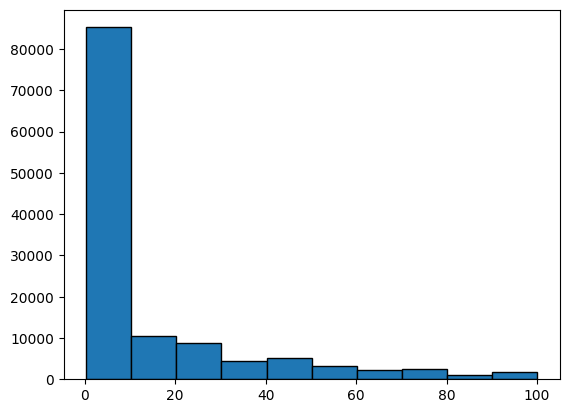

In [101]:
plt.hist(data=df[df.response_time<100],x='response_time',edgecolor='black')
plt.show()

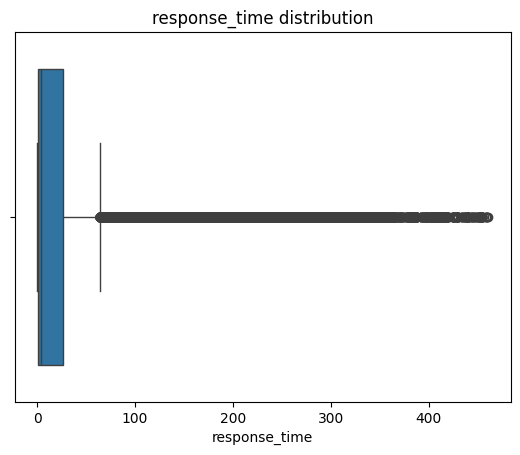

In [102]:
sns.boxplot(data=df,x='response_time')
plt.title('response_time distribution')
plt.show()

In [103]:
df.response_time.describe()
# Almost 75% of SR are resolved within a day 24 hours

count    135857.000000
mean         27.516952
std          54.626308
min           0.330000
25%           1.259167
50%           4.002222
75%          26.549167
max         460.916667
Name: response_time, dtype: float64

In [104]:
print(df[df.response_time<26].shape[0])
print(df[df.response_time>26].shape[0])
# Since like there is a class imbalance , well its a cts variable so idk what imbalance , but uhh we are more likely to predict < 26 hours than > 26

101429
34427


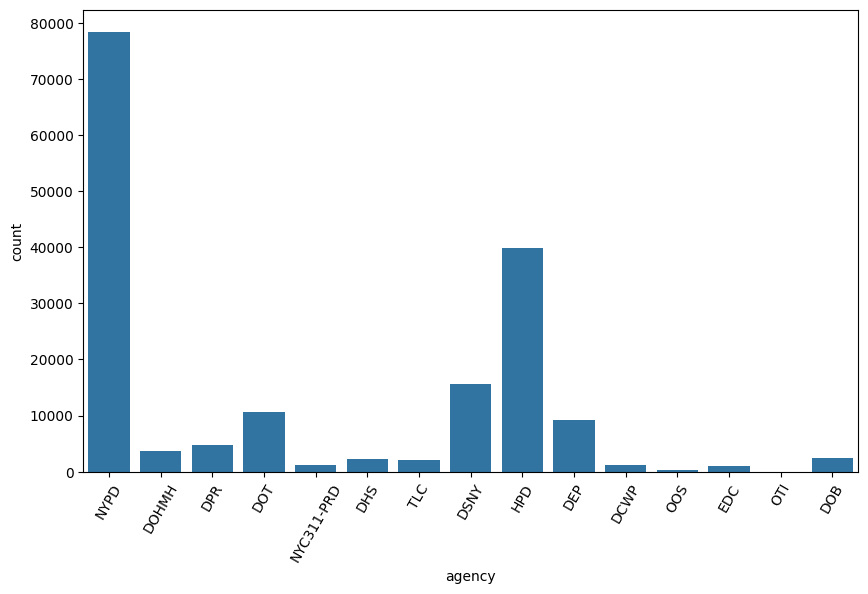

In [105]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='agency')
plt.xticks(rotation=60)
plt.show()

In [106]:
with pd.option_context('display.max_rows', None, 
                       'display.max_columns', None):
    display(df.groupby(['agency_name','complaint_type']).size())

agency_name                                         complaint_type                         
Department of Buildings                             AHV Inspection Unit                            1
                                                    BEST/Site Safety                              14
                                                    Boilers                                       16
                                                    Building Marshal's Office                      1
                                                    Building/Use                                 205
                                                    Construction Safety Enforcement                2
                                                    Cranes and Derricks                            1
                                                    Electrical                                   119
                                                    Elevator                                     530

In [107]:
ts = df.groupby('complaint_type')['response_time'].mean().sort_values(ascending=False)
ts.fillna(value=0,inplace=True)

with pd.option_context('display.max_rows', None, 
                       'display.max_columns', None):
        display(ts)
        
index = ts.index 

complaint_type
For Hire Vehicle Complaint                 233.363781
Curb Condition                             217.068395
Taxi Complaint                             211.333889
Non-Residential Heat                       210.303333
Cannabis Retailer                          209.846865
Smoking or Vaping                          157.692079
Outdoor Dining                             148.676319
AHV Inspection Unit                        147.904722
UNSANITARY CONDITION                       143.330892
ELEVATOR                                   141.195443
APPLIANCE                                  138.512240
GENERAL                                    138.383079
DOOR/WINDOW                                137.438885
FLOORING/STAIRS                            135.907931
OUTSIDE BUILDING                           135.669547
WATER LEAK                                 134.511657
Sidewalk Condition                         131.758526
Public Toilet                              130.411944
Special Proje

In [108]:
with pd.option_context('display.max_rows',None,
                       'display.max_columns',None):
    display(df.complaint_type.value_counts()[index])

complaint_type
For Hire Vehicle Complaint                  1081
Curb Condition                               616
Taxi Complaint                               589
Non-Residential Heat                          19
Cannabis Retailer                            234
Smoking or Vaping                            448
Outdoor Dining                               224
AHV Inspection Unit                            1
UNSANITARY CONDITION                        6466
ELEVATOR                                     105
APPLIANCE                                   1207
GENERAL                                     2004
DOOR/WINDOW                                 2707
FLOORING/STAIRS                             1695
OUTSIDE BUILDING                              57
WATER LEAK                                  1957
Sidewalk Condition                          1449
Public Toilet                                  1
Special Projects Inspection Team (SPIT)       31
Emergency Response Team (ERT)                102
Inves

In [109]:
fa = df.complaint_type.value_counts()[index].sort_values(ascending=False)
fa.sum()


np.int64(172555)

In [110]:
(101740/172555) * 100

58.96091101387964

In [111]:
df.complaint_type.value_counts()[index].sort_values(ascending=False)[:10]

complaint_type
Illegal Parking            29379
Noise - Residential        18451
HEAT/HOT WATER             13754
Blocked Driveway            8694
Noise - Street/Sidewalk     7558
UNSANITARY CONDITION        6466
Street Condition            5224
PLUMBING                    4160
Abandoned Vehicle           4133
Dirty Condition             3921
Name: count, dtype: int64

In [112]:
ts.loc[fa.index][:10]

complaint_type
Illegal Parking              2.907737
Noise - Residential          2.810651
HEAT/HOT WATER              32.437203
Blocked Driveway             2.996238
Noise - Street/Sidewalk      2.330690
UNSANITARY CONDITION       143.330892
Street Condition            77.587621
PLUMBING                   105.232576
Abandoned Vehicle            4.135966
Dirty Condition             33.471104
Name: response_time, dtype: float64

In [113]:
[ts.loc[fa.index][:10].index]

[Index(['Illegal Parking', 'Noise - Residential', 'HEAT/HOT WATER',
        'Blocked Driveway', 'Noise - Street/Sidewalk', 'UNSANITARY CONDITION',
        'Street Condition', 'PLUMBING', 'Abandoned Vehicle', 'Dirty Condition'],
       dtype='str', name='complaint_type')]

In [114]:
df.loc[df.complaint_type.isin(ts.loc[fa.index][:10].index),
       ].groupby(['complaint_type','agency']).size()

complaint_type           agency    
Abandoned Vehicle        NYPD           4133
Blocked Driveway         NYPD           8694
Dirty Condition          DSNY           3921
HEAT/HOT WATER           HPD           13754
Illegal Parking          NYPD          29379
Noise - Residential      NYPD          18451
Noise - Street/Sidewalk  NYPD           7558
PLUMBING                 HPD            4160
Street Condition         DOT            4437
                         NYC311-PRD      787
UNSANITARY CONDITION     HPD            6466
dtype: int64

In [115]:
with pd.option_context('display.max_rows', None, 
                       'display.max_columns', None):
        display(df.loc[df.agency.isin(['NYPD','HPD','DSNY','DOT','NYC311-PRD'])].groupby(['agency','complaint_type'])['response_time'].mean())

agency      complaint_type                        
DOT         Bench                                            NaN
            Bike Rack                                  77.384722
            Broken Parking Meter                       56.905093
            Bus Stop Shelter Complaint                 81.022899
            Bus Stop Shelter Placement                 25.654190
            Curb Condition                            158.224110
            E-Scooter                                  33.405257
            Leaning Bar                                      NaN
            Outdoor Dining                                   NaN
            Public Toilet                             130.411944
            Sidewalk Condition                        135.930596
            Street Condition                           80.368743
            Street Light Condition                     96.469335
            Street Sign - Damaged                      84.455938
            Street Sign - Dangling     

In [116]:
%matplotlib widget
fig = px.scatter(
    x=np.log(df.complaint_type.value_counts()[index]),
    y=ts,
    hover_name=ts.index,
    hover_data = [df.complaint_type.value_counts()[index]]
)

fig.update_layout(
    title='Response time mean vs No of complaints grouped by complaint type',
    xaxis_title = 'No of complaints(scaled)',
    yaxis_title = 'Mean response time',
    width=1000,
    height=600
)

fig.show()

In [117]:
%matplotlib inline

In [118]:
with pd.option_context('display.max_rows', None, 
                       'display.max_columns', None):
        display(df.groupby(['agency','complaint_type'])['response_time'].mean())

agency      complaint_type                         
DCWP        Consumer Complaint                          54.334147
DEP         Air Quality                                 76.117595
            Asbestos                                    10.633333
            Hazardous Materials                          2.085897
            Industrial Waste                            12.614493
            Lead                                        28.081308
            Noise                                       75.474324
            Plant                                        1.313889
            Sewer                                       22.757322
            Water Conservation                          27.005046
            Water Quality                               81.477928
            Water System                                35.352804
DHS         Encampment                                  37.601441
            Homeless Person Assistance                   6.132549
DOB         AHV Inspecti

count       Axes(0.125,0.11;0.352273x0.77)
mean     Axes(0.547727,0.11;0.352273x0.77)
dtype: object

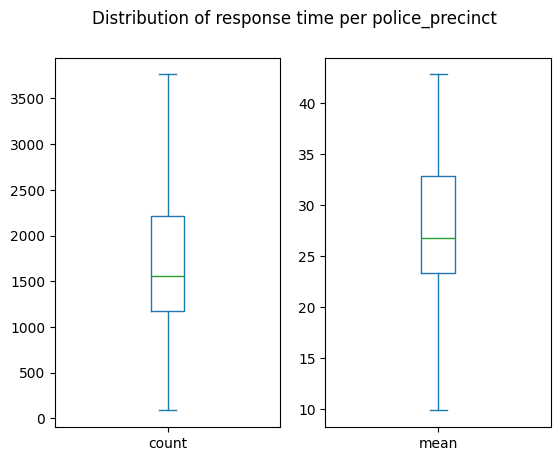

In [119]:
df.groupby('police_precinct')['response_time'].agg(['count','mean']).plot(kind='box',title='Distribution of response time per police_precinct',subplots=True)

In [120]:
with pd.option_context('display.max_rows', None, 
                       'display.max_columns', None):
        display(df.groupby('police_precinct')['response_time'].agg(['count','mean']).sort_values(by='count',ascending=False))

,count,mean
police_precinct,,
Precinct 114,3762,19.707460
Precinct 47,3663,22.449668
Precinct 104,3558,19.026018
Precinct 44,3473,42.813565
Precinct 75,3447,30.187209
Precinct 109,3147,24.940300
Precinct 46,3138,35.246506
Precinct 70,2960,32.828672
Precinct 62,2945,18.636898


<Axes: xlabel='count'>

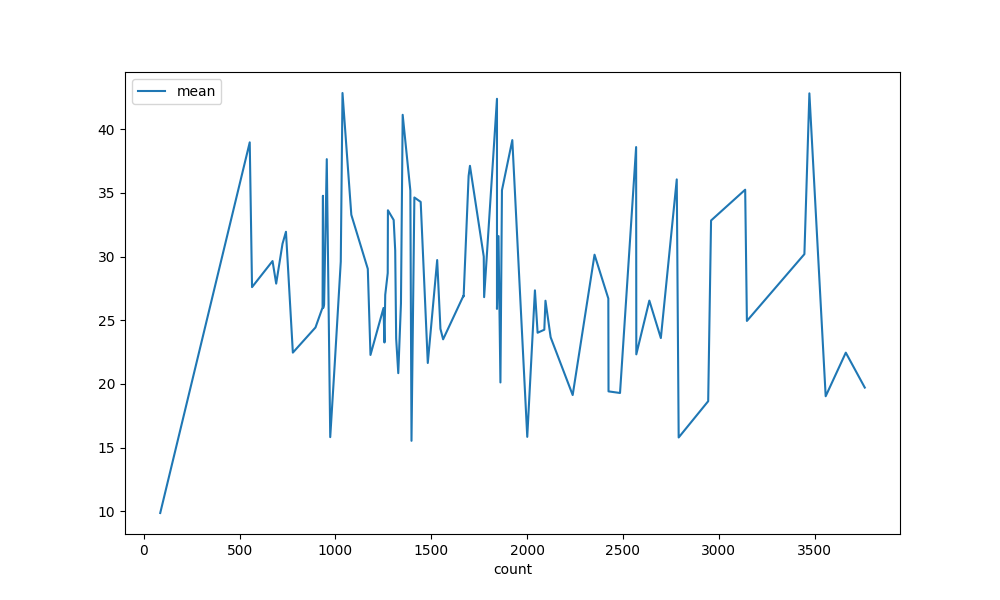

In [121]:
%matplotlib widget
df.groupby('police_precinct')['response_time'].agg(['count','mean']).sort_values(by='count').plot(x='count',y='mean',kind='line',figsize=(10,6))

In [122]:
%matplotlib inline

In [123]:
df.groupby(['complaint_type','address_type']).size().loc['Noise']

address_type
ADDRESS         3446
INTERSECTION     349
dtype: int64

In [124]:
df.groupby('address_type').size()

address_type
ADDRESS         158161
BLOCKFACE            7
INTERSECTION     13086
PLACE             1249
PLACENAME           52
dtype: int64

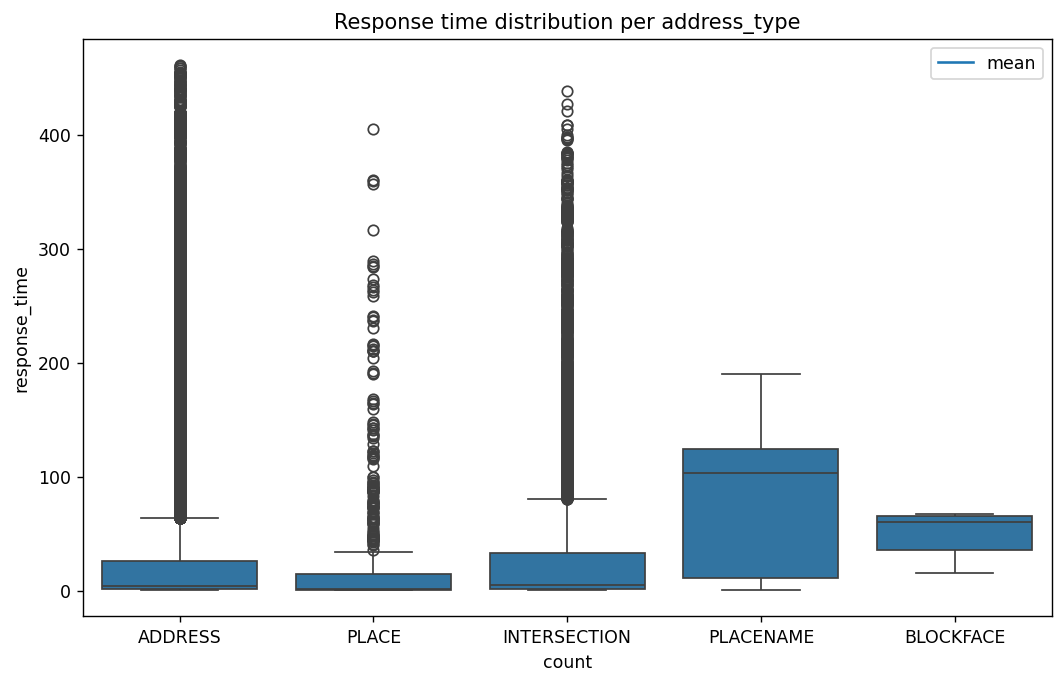

In [125]:
sns.boxplot(data=df,x='address_type',y='response_time')
plt.title('Response time distribution per address_type')
plt.show()

In [126]:
df.latitude.agg(['min','max'])
# How can I find out regions where the mean response time is highest , is this possible? because response time is also affected by complaint type so . it mainly depends on the complaint type that how long it could take to be resolved

min    40.498044
max    40.912828
Name: latitude, dtype: float64

In [127]:
display(df.groupby(['police_precinct','complaint_type']).size())

police_precinct  complaint_type     
Precinct 1       Abandoned Bike          1
                 Abandoned Vehicle       8
                 Air Quality            19
                 Animal in a Park        2
                 Animal-Abuse            2
                                        ..
Unspecified      Urinating in Public     2
                 Vendor Enforcement      9
                 WATER LEAK              3
                 Water Conservation      2
                 Water System           53
Length: 6809, dtype: int64

In [128]:
# The types of complaints that have been seen in a police_precinct above a specfic amount should have lower response time because they authorities know that this problem is common so they should be prepared to handle it leading to lower the overall mean response time for that complaint_type in that police precinct 

# Over the month we should have seen a specific complaint type , more in some areas , so we expect it to be more in the future as well 

# Over the various complaint types , its not necessary that a specific complaint comes in every police_precinct . So we pick a number lets say 3 and then compare its idk response time maybe or count as well over the various precinct 

In [129]:
myList = (df.groupby('complaint_type').size()).sort_values(ascending=False)[:5]
myList

complaint_type
Illegal Parking            29379
Noise - Residential        18451
HEAT/HOT WATER             13754
Blocked Driveway            8694
Noise - Street/Sidewalk     7558
dtype: int64

In [130]:
s = df[(df['complaint_type'].isin(myList.index)) & (~df['police_precinct'].isin(['Unspecified']))].groupby(['police_precinct','complaint_type']).size()
s

police_precinct  complaint_type         
Precinct 1       Blocked Driveway            23
                 HEAT/HOT WATER              45
                 Illegal Parking            224
                 Noise - Residential         72
                 Noise - Street/Sidewalk     85
                                           ... 
Precinct 94      Blocked Driveway            99
                 HEAT/HOT WATER              74
                 Illegal Parking            517
                 Noise - Residential        147
                 Noise - Street/Sidewalk     67
Length: 380, dtype: int64

In [131]:
def compare_distributions(arr1,arr2):
    count = 0
    total = 0
    for a in arr1:
        for b in arr2:
            if a<b:
                count+=1
            total+=1

    if (arr1.shape[0]*arr2.shape[0] - count)> count:
        return arr1  #arr1 is smaller
    else:
        return arr2
    return count/total

In [132]:
si = s.loc[:,'Illegal Parking']

In [154]:
def final_sum(complaint,df):
    final_sum = np.array([])

    ts = df.loc[(df.complaint_type == complaint) & (~df['police_precinct'].isin(['Unspecified'])),'response_time']
    ts = ts.drop(ts[ts.isna()].index,axis=0)
    ts.index = df.loc[ts.index,'police_precinct']
    ts = ts.sort_values()

    ts_abridged = ts[::100]
    for i in ts.index.unique():
        k = df.loc[df.police_precinct == i,'response_time']
        c = np.searchsorted(ts_abridged,k,side='left')
        for j in range(k.shape[0]):
            c[j] = c[j]*100 + np.searchsorted(ts.iloc[c[j]*100 : (c[j]*100)+100],k.iloc[j],side='left')
        final_sum = np.append(final_sum,np.sum(c))

    final_sum = pd.Series(final_sum,index=ts.index.unique()).sort_values()
    si = s.loc[:,complaint]
    y = si.loc[final_sum.index]
    return final_sum,y


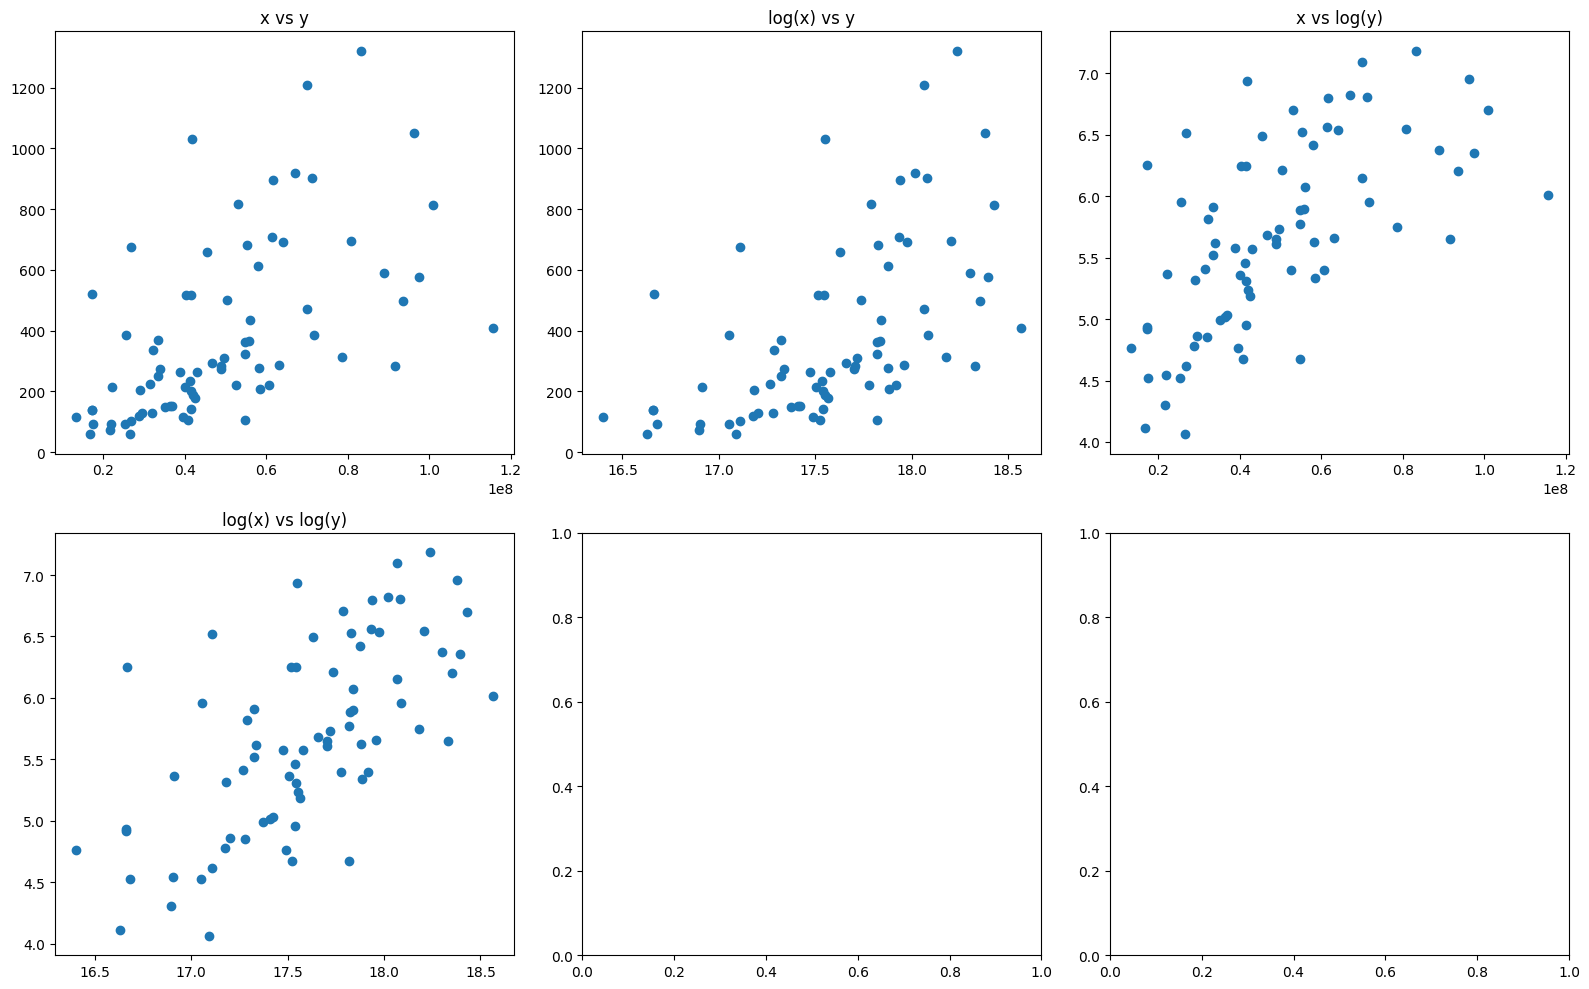

In [172]:
x,y = final_sum('Illegal Parking',df)
n_cols = 3
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10))
axes = axes.flatten()

axes[0].scatter(x, y)
axes[1].scatter(np.log(x), y)
axes[2].scatter(x, np.log(y))
axes[3].scatter(np.log(x), np.log(y))


axes[0].set_title("x vs y")
axes[1].set_title("log(x) vs y")
axes[2].set_title("x vs log(y)")
axes[3].set_title("log(x) vs log(y)")

plt.tight_layout()
plt.show()

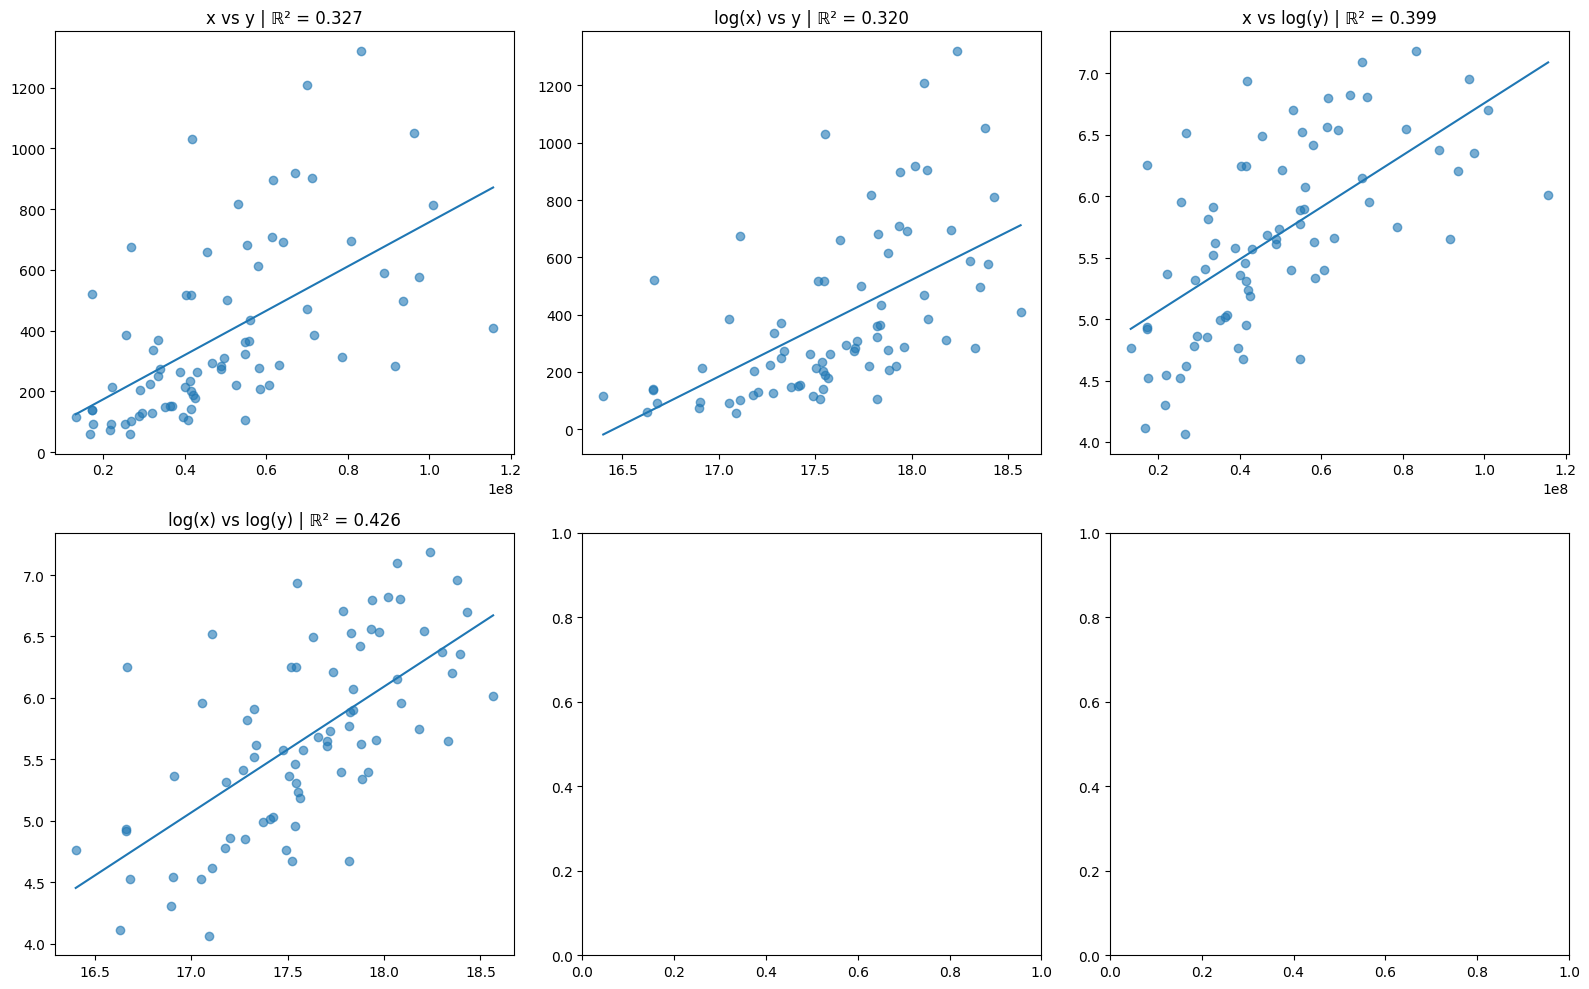

In [173]:
def fit_and_plot1(ax, X, Y, title):
    X = np.array(X)
    model = LinearRegression()
    X_reshaped = X.reshape(-1,1)
    model.fit(X_reshaped, Y)

    Y_pred = model.predict(X_reshaped)

    ax.scatter(X, Y, alpha=0.6)
    ax.plot(X, Y_pred)
    ax.set_title(f"{title} | ℝ² = {model.score(X_reshaped, Y):.3f}")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10))
axes = axes.flatten()

fit_and_plot1(axes[0], x, y, "x vs y")
fit_and_plot1(axes[1], np.log(x), y, "log(x) vs y")
fit_and_plot1(axes[2], x,np.log(y), "x vs log(y)")
fit_and_plot1(axes[3], np.log(x), np.log(y), "log(x) vs log(y)")

plt.tight_layout()
plt.show()

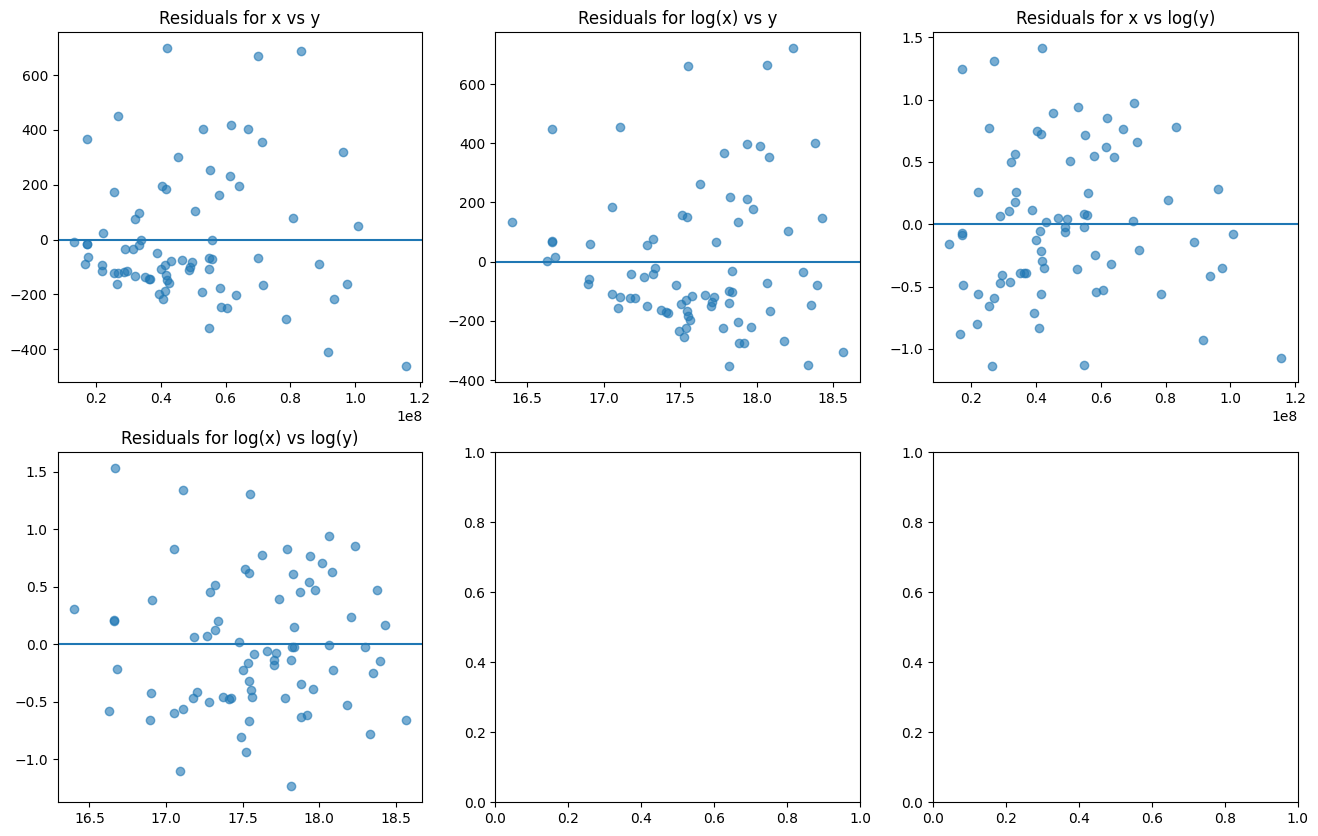

In [174]:
def fit_and_plot2(ax, X, Y, title):
    X = np.array(X)
    model = LinearRegression()
    X_reshaped = X.reshape(-1,1)
    model.fit(X_reshaped, Y)

    Y_pred = model.predict(X_reshaped)
    residuals = Y - Y_pred

    ax.scatter(X, residuals, alpha=0.6)
    ax.axhline(0)
    ax.set_title(f"Residuals for {title}")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10))
axes = axes.flatten()

fit_and_plot2(axes[0], x, y, "x vs y")
fit_and_plot2(axes[1], np.log(x), y, "log(x) vs y")
fit_and_plot2(axes[2], x,np.log(y), "x vs log(y)")
fit_and_plot2(axes[3], np.log(x), np.log(y), "log(x) vs log(y)")

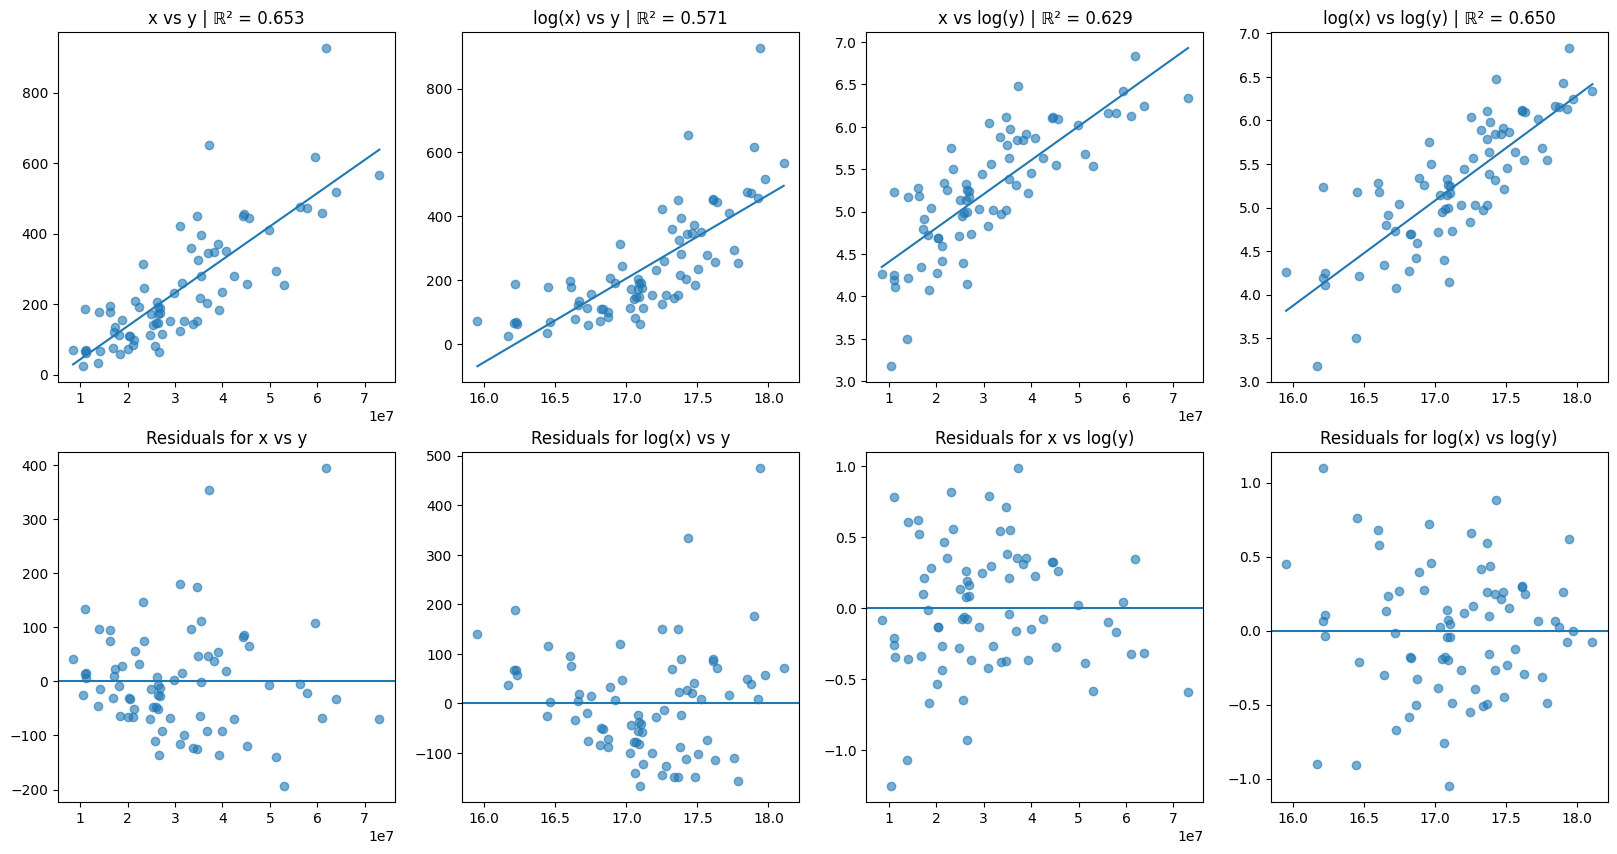

In [158]:
x,y = final_sum('Noise - Residential',df)
n_cols = 4
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10))
axes = axes.flatten()

fit_and_plot1(axes[0], x, y, "x vs y")
fit_and_plot1(axes[1], np.log(x), y, "log(x) vs y")
fit_and_plot1(axes[2], x,np.log(y), "x vs log(y)")
fit_and_plot1(axes[3], np.log(x), np.log(y), "log(x) vs log(y)")

fit_and_plot2(axes[4], x, y, "x vs y")
fit_and_plot2(axes[5], np.log(x), y, "log(x) vs y")
fit_and_plot2(axes[6], x,np.log(y), "x vs log(y)")
fit_and_plot2(axes[7], np.log(x), np.log(y), "log(x) vs log(y)")

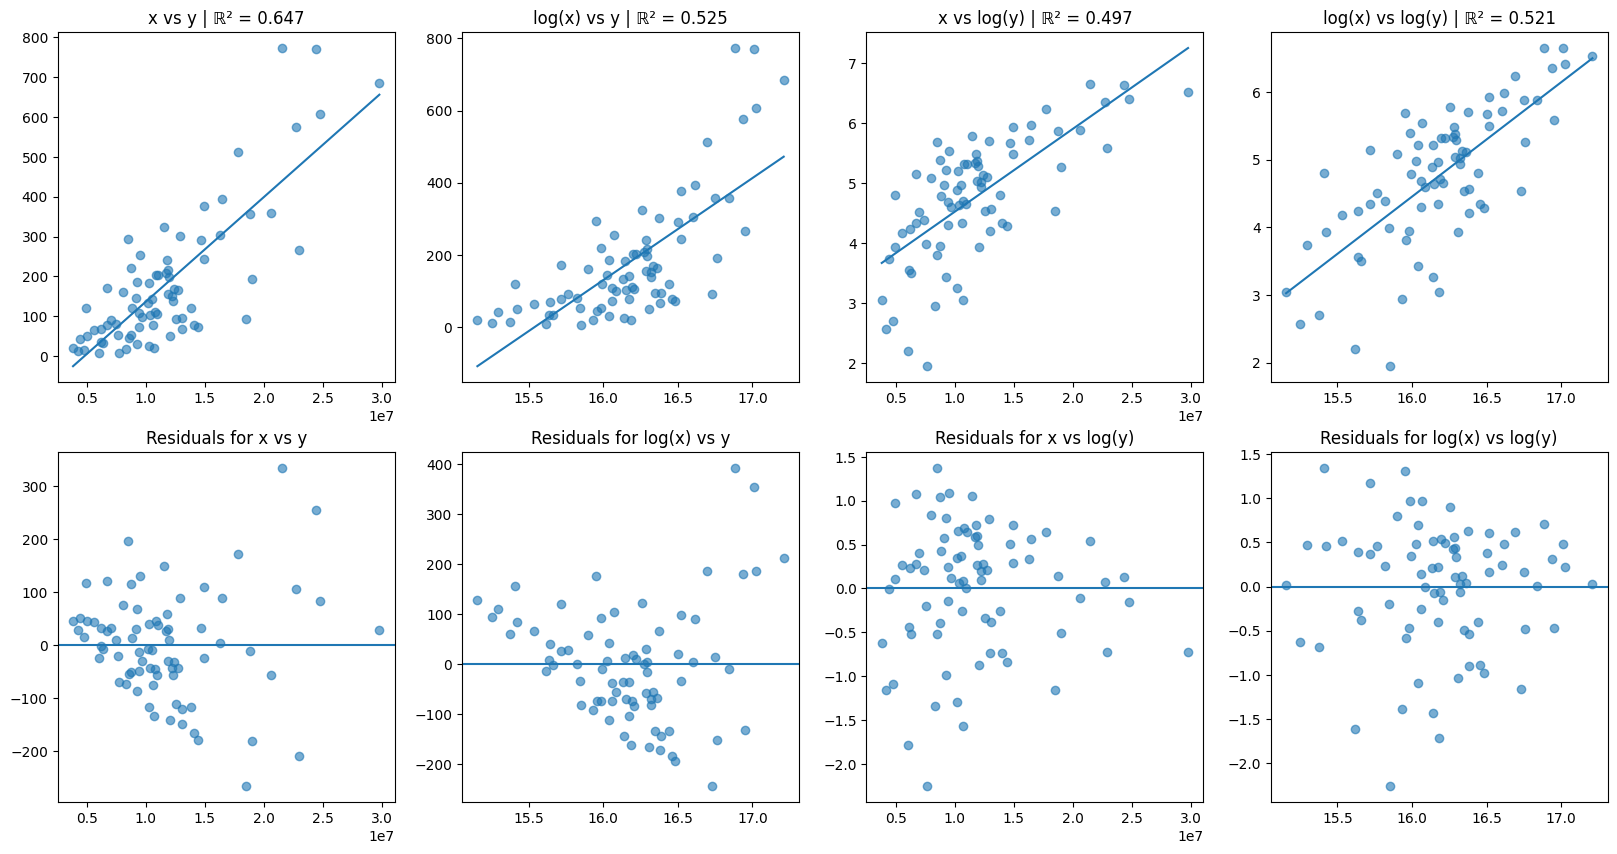

In [159]:
x,y = final_sum('HEAT/HOT WATER',df)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10))
axes = axes.flatten()

fit_and_plot1(axes[0], x, y, "x vs y")
fit_and_plot1(axes[1], np.log(x), y, "log(x) vs y")
fit_and_plot1(axes[2], x,np.log(y), "x vs log(y)")
fit_and_plot1(axes[3], np.log(x), np.log(y), "log(x) vs log(y)")

fit_and_plot2(axes[4], x, y, "x vs y")
fit_and_plot2(axes[5], np.log(x), y, "log(x) vs y")
fit_and_plot2(axes[6], x,np.log(y), "x vs log(y)")
fit_and_plot2(axes[7], np.log(x), np.log(y), "log(x) vs log(y)")

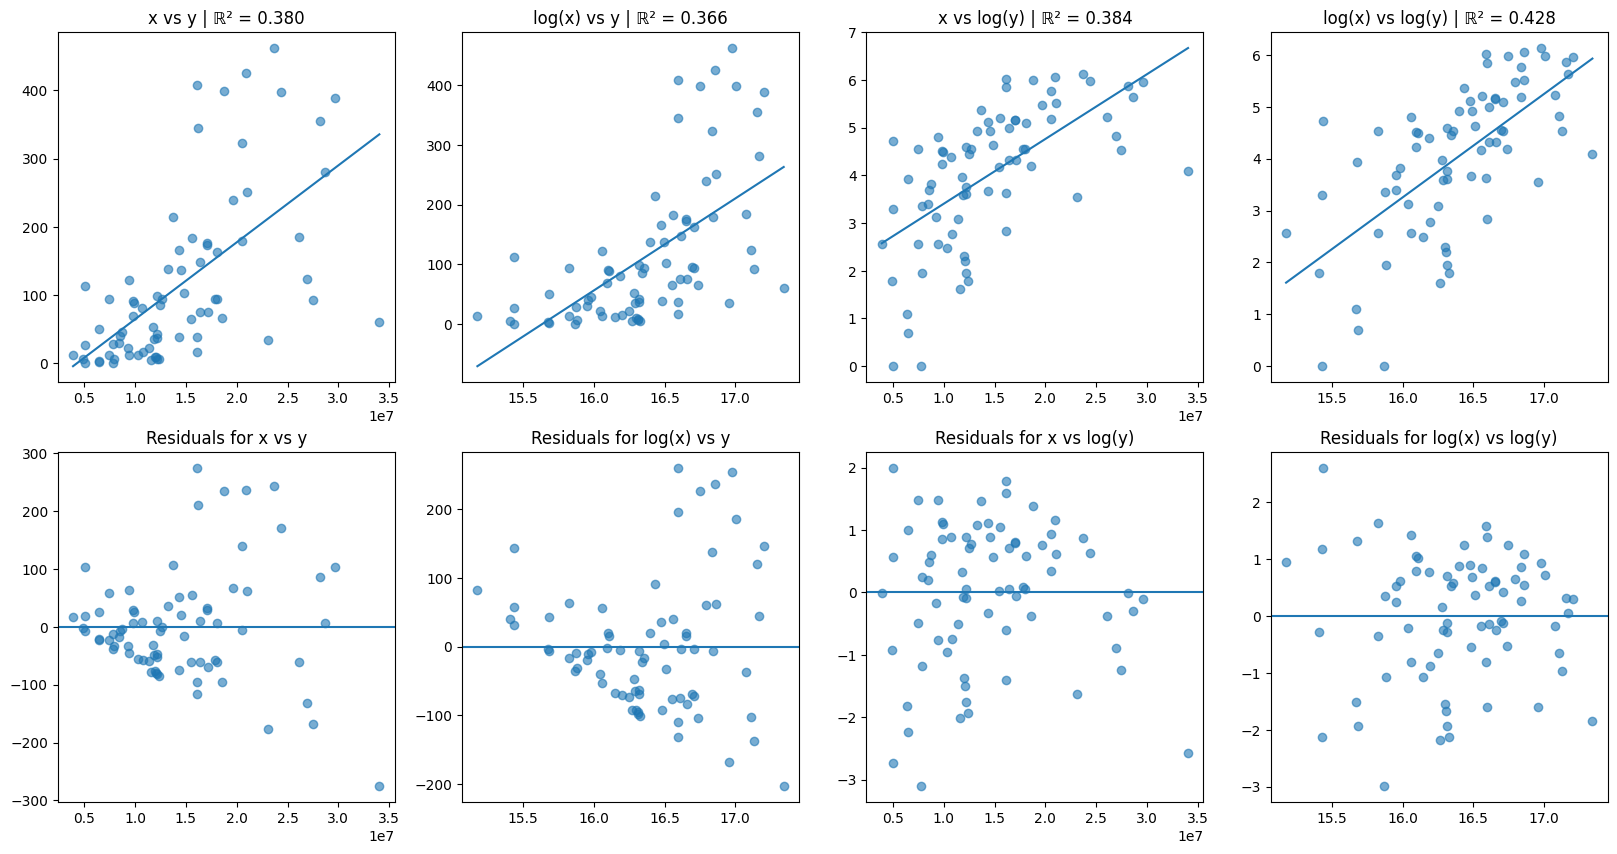

In [160]:
x,y = final_sum('Blocked Driveway',df)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10))
axes = axes.flatten()

fit_and_plot1(axes[0], x, y, "x vs y")
fit_and_plot1(axes[1], np.log(x), y, "log(x) vs y")
fit_and_plot1(axes[2], x,np.log(y), "x vs log(y)")
fit_and_plot1(axes[3], np.log(x), np.log(y), "log(x) vs log(y)")

fit_and_plot2(axes[4], x, y, "x vs y")
fit_and_plot2(axes[5], np.log(x), y, "log(x) vs y")
fit_and_plot2(axes[6], x,np.log(y), "x vs log(y)")
fit_and_plot2(axes[7], np.log(x), np.log(y), "log(x) vs log(y)")

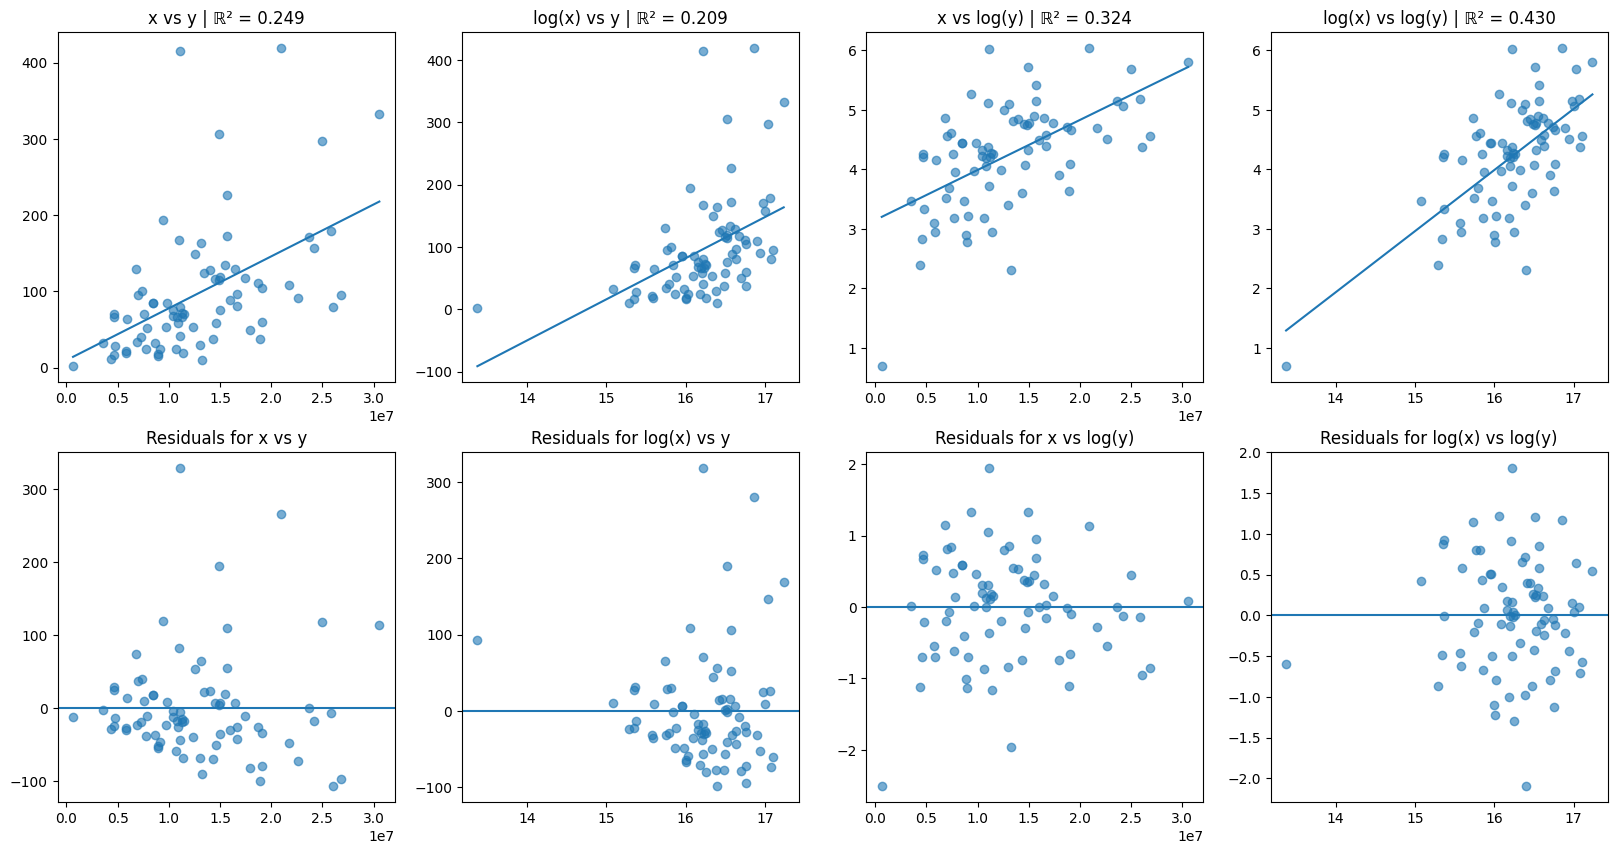

In [161]:
x,y = final_sum('Noise - Street/Sidewalk',df)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10))
axes = axes.flatten()

fit_and_plot1(axes[0], x, y, "x vs y")
fit_and_plot1(axes[1], np.log(x), y, "log(x) vs y")
fit_and_plot1(axes[2], x,np.log(y), "x vs log(y)")
fit_and_plot1(axes[3], np.log(x), np.log(y), "log(x) vs log(y)")

fit_and_plot2(axes[4], x, y, "x vs y")
fit_and_plot2(axes[5], np.log(x), y, "log(x) vs y")
fit_and_plot2(axes[6], x,np.log(y), "x vs log(y)")
fit_and_plot2(axes[7], np.log(x), np.log(y), "log(x) vs log(y)")

In [162]:
x.sort_values()

police_precinct
Precinct 22       644400.0
Precinct 100     3546900.0
Precinct 17      4365700.0
Precinct 69      4622800.0
Precinct 7       4653900.0
                   ...    
Precinct 46     24948600.0
Precinct 114    25882500.0
Precinct 47     26076900.0
Precinct 75     26837300.0
Precinct 44     30569900.0
Length: 77, dtype: float64

In [163]:
s.loc[:,'Illegal Parking'].index

Index(['Precinct 1', 'Precinct 10', 'Precinct 100', 'Precinct 101',
       'Precinct 102', 'Precinct 103', 'Precinct 104', 'Precinct 105',
       'Precinct 106', 'Precinct 107', 'Precinct 108', 'Precinct 109',
       'Precinct 110', 'Precinct 111', 'Precinct 112', 'Precinct 113',
       'Precinct 114', 'Precinct 115', 'Precinct 120', 'Precinct 121',
       'Precinct 122', 'Precinct 123', 'Precinct 13', 'Precinct 14',
       'Precinct 17', 'Precinct 18', 'Precinct 19', 'Precinct 20',
       'Precinct 23', 'Precinct 24', 'Precinct 25', 'Precinct 26',
       'Precinct 28', 'Precinct 30', 'Precinct 32', 'Precinct 33',
       'Precinct 34', 'Precinct 40', 'Precinct 41', 'Precinct 42',
       'Precinct 43', 'Precinct 44', 'Precinct 45', 'Precinct 46',
       'Precinct 47', 'Precinct 48', 'Precinct 49', 'Precinct 5',
       'Precinct 50', 'Precinct 52', 'Precinct 6', 'Precinct 60',
       'Precinct 61', 'Precinct 62', 'Precinct 63', 'Precinct 66',
       'Precinct 67', 'Precinct 68', 'Precinc

In [164]:
df.police_precinct.unique()

<StringArray>
[ 'Precinct 75',  'Precinct 34', 'Precinct 102',  'Precinct 77',
  'Precinct 81',  'Precinct 94',  'Precinct 24',  'Precinct 45',
  'Precinct 60',  'Precinct 79',  'Precinct 62',  'Precinct 46',
  'Precinct 52', 'Precinct 101',  'Precinct 32',  'Precinct 47',
  'Precinct 78',  'Precinct 23', 'Precinct 108',  'Precinct 48',
  'Precinct 68',  'Precinct 40', 'Precinct 111',  'Precinct 50',
  'Precinct 70', 'Precinct 103', 'Precinct 107', 'Precinct 113',
  'Precinct 30',  'Precinct 44',  'Precinct 76',  'Precinct 63',
  'Precinct 84',  'Precinct 66', 'Precinct 109',  'Precinct 49',
  'Precinct 67',  'Precinct 90',  'Precinct 88',  'Precinct 72',
   'Precinct 7',  'Precinct 42', 'Precinct 110',  'Precinct 18',
   'Precinct 1',  'Unspecified',  'Precinct 71',  'Precinct 61',
 'Precinct 115',   'Precinct 5', 'Precinct 114', 'Precinct 106',
  'Precinct 83',  'Precinct 73', 'Precinct 105',  'Precinct 10',
 'Precinct 104',  'Precinct 25',   'Precinct 9',  'Precinct 43',
  'Precinct

In [165]:
d = s.loc[:,"Illegal Parking"]
for i in range(0,94,2):
    print(i)

0
2
4
6
8
10
12
14
16
18
20
22
24
26
28
30
32
34
36
38
40
42
44
46
48
50
52
54
56
58
60
62
64
66
68
70
72
74
76
78
80
82
84
86
88
90
92


In [166]:
#plt.plot(s.loc[:,'Illegal Parking'])

In [167]:
# Q) Do specific police_precinct have lower response_time ( bhul jao complaint type abhi ke liye )
# Ans) check distribution : box plot , if there are outliers then well evaluate what that outlier is telling me . But still below Q3 we do have 75% of the data so even that portion should roughly tell us the response time range as for the 25% data left above Q3 , since there is no guarantee that x percentage of data is between the top whisker and above Q3 , maybe I should check another boxplot ? 

In [168]:
df[df.police_precinct=='Unspecified'].shape[0]
# drop or keep?
# The amount of unpsecified we have is quite balanced, its a healthy amount , can we extract patterns from this too , its between Q3-Q1
# No we shouldn't , its unspecified because we don't know its police precinct
# or we could because ,it would tell us how a SR was handled when its police precinct was not specified , now we expect two cases here , either its police_precinct is unspecified because the system assigned it or maybe due to some error , we don't know when there was a error so we just we are not gonna consider this part   

1595

In [169]:
# agency, complaint_type , police precinict , address_type 
# lattiude , longitude

In [170]:
df.info()

<class 'pandas.DataFrame'>
Index: 172555 entries, 5 to 199999
Data columns (total 52 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   unique_key                              172555 non-null  int64         
 1   created_date                            172555 non-null  datetime64[us]
 2   closed_date                             135857 non-null  datetime64[us]
 3   agency                                  172555 non-null  str           
 4   agency_name                             172555 non-null  str           
 5   complaint_type                          172555 non-null  str           
 6   descriptor                              169861 non-null  str           
 7   descriptor_2                            69600 non-null   str           
 8   location_type                           153758 non-null  str           
 9   incident_zip                            172554 non-nu

#### Hide

##### 5. Data transformations

$$\huge \texttt{Data pre-processing}$$
$$\normalsize \texttt{In this section , We are gonna prepare our data for model input}$$

In [171]:
# OneHot-Encoding all the categorical columns at once
"""
X_train , X_test , y_train , y_test = train_test_split(...)

X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Train and test might have different categories 
#ex Train has : A, B and Test has : A, C , so columns don't match
#This makes sure , both have same columns , missing ones are filled with 0
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
"""

"\nX_train , X_test , y_train , y_test = train_test_split(...)\n\nX_train = pd.get_dummies(X_train)\nX_test = pd.get_dummies(X_test)\n\n# Train and test might have different categories \n#ex Train has : A, B and Test has : A, C , so columns don't match\n#This makes sure , both have same columns , missing ones are filled with 0\nX_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)\n"

##### 6. Training

$$\huge \texttt{Model Training}$$
$$\normalsize \texttt{Training the model / trying out different things with the model and improving the result of desired metrics}$$

##### 7. evaluation

$$\huge \texttt{Model evaluation / interpretation}$$
$$\normalsize \texttt{We showcase and interpret the result here}$$